# Cross-study marker profile matching

This notebook loads raw marker extraction output from the BioRxiv and HCA corpora,
filters to a shared high-confidence cohort, and compares paper-level marker profiles.
The goal is to surface two cross-study signals enabled by machine-readable markers:

- different cell type names with similar marker profiles
- the same cell type name used with different marker profiles

The notebook writes a canonical cached table for the filtered cohort so downstream
figures and tables can reuse the exact same input.

In [1]:
import json
import os
import re
import unicodedata
import warnings
from collections import defaultdict
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sentence_transformers import SentenceTransformer

warnings.simplefilter(action='ignore', category=Warning)

fsize = 10
plt.rcParams.update({"font.size": fsize})
%config InlineBackend.figure_format = 'retina'
pd.set_option('display.max_colwidth', 160)
pd.set_option('display.max_rows', 100)

## Config

In [2]:
def find_repo_root() -> Path:
    cwd = Path.cwd().resolve()
    for candidate in [cwd, *cwd.parents]:
        if (candidate / 'analysis').exists() and (candidate / 'data').exists():
            return candidate
    raise RuntimeError('Could not locate repo root from current working directory.')

REPO_ROOT = find_repo_root()
ANALYSIS_DIR = REPO_ROOT / 'analysis'
RESULTS_DIR = ANALYSIS_DIR / 'results'
FIGURES_DIR = ANALYSIS_DIR / 'figures'
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

DATASETS = {
    'biorxiv': REPO_ROOT / 'data' / 'biorxiv' / 'meca',
    'hca': REPO_ROOT / 'data' / 'hca' / 'manuscripts',
}

RECORDS_CACHE = RESULTS_DIR / 'cross_study_marker_records.tsv'
PROFILE_CACHE = RESULTS_DIR / 'cross_study_profile_summary.tsv'
PAIR_CACHE = RESULTS_DIR / 'cross_study_candidate_profile_pairs.tsv'
SAME_NAME_CACHE = RESULTS_DIR / 'cross_study_same_name_pairs.tsv'
NEAREST_NEIGHBOR_CACHE = RESULTS_DIR / 'cross_study_nearest_marker_neighbors.tsv'
LABEL_NEIGHBOR_CACHE = RESULTS_DIR / 'cross_study_nearest_label_neighbors.tsv'
MARKER_LABEL_ALIGNMENT_CACHE = RESULTS_DIR / 'cross_study_marker_label_alignment.tsv'
MARKER_NEIGHBOR_SPACE_COMPARE_CACHE = RESULTS_DIR / 'cross_study_marker_neighbor_space_compare.tsv'
TOP_DIFF_CACHE = RESULTS_DIR / 'cross_study_top_different_name_matches.tsv'
TOP_SAME_CACHE = RESULTS_DIR / 'cross_study_top_same_name_divergent_pairs.tsv'
IMMUNE_CACHE = RESULTS_DIR / 'cross_study_monocyte_macrophage_pairs.tsv'
PAIRWISE_FIG_PNG = FIGURES_DIR / 'cross_study_pairwise_jaccard.png'
PAIRWISE_FIG_PDF = FIGURES_DIR / 'cross_study_pairwise_jaccard.pdf'
MINILM_SNAPSHOT_DIR = sorted((Path.home() / '.cache' / 'huggingface' / 'hub' / 'models--sentence-transformers--all-MiniLM-L6-v2' / 'snapshots').glob('*'))[-1]

MIN_MARKERS = 3
HIGH_JACCARD = 0.50
LABEL_TOPK = 5
IMMUNE_PATTERN = re.compile(r'MONOCYTE|MACROPHAGE')
WRITE_INTERMEDIATE_TABLES = False
WRITE_INTERMEDIATE_FIGURES = False


def maybe_write_table(df, path, *, index=False):
    if WRITE_INTERMEDIATE_TABLES:
        df.to_csv(path, sep='\t', index=index)
        print(f'Wrote {path.relative_to(REPO_ROOT)}')

for name, path in DATASETS.items():
    print(f'{name}: {path}')

biorxiv: /Users/sinabooeshaghi/projects/markergeneextraction/llmarkers/data/biorxiv/meca
hca: /Users/sinabooeshaghi/projects/markergeneextraction/llmarkers/data/hca/manuscripts


## Load raw marker records

In [3]:
def clean_text(value: object) -> str:
    return re.sub(r'\s+', ' ', str(value or '')).strip()


def clean_upper(value: object) -> str:
    return clean_text(value).upper()


def normalize_label_for_embedding(value: object) -> str:
    text = clean_text(value)
    text = unicodedata.normalize('NFKD', text).encode('ascii', 'ignore').decode('ascii')
    text = re.sub(r'[_/\-]+', ' ', text)
    text = re.sub(r'(?<=[A-Za-z])(?=[0-9])', ' ', text)
    text = re.sub(r'(?<=[0-9])(?=[A-Za-z])', ' ', text)
    text = re.sub(r'\s+', ' ', text).strip().lower()
    return text


def maybe_float(value: object):
    if value in (None, ''):
        return np.nan
    try:
        return float(value)
    except (TypeError, ValueError):
        return np.nan


def extract_hca_doi(folder_name: str) -> str:
    parts = folder_name.split('_')
    if len(parts) >= 3 and parts[1].startswith('10.'):
        return parts[1]
    return ''


def iter_marker_records(source_corpus: str, base_dir: Path):
    for markers_path in sorted(base_dir.rglob('markers.json')):
        paper_dir = markers_path.parent
        if not paper_dir.is_dir():
            continue
        try:
            markers = json.loads(markers_path.read_text())
        except Exception:
            continue
        if not isinstance(markers, list):
            continue

        manuscript_path = paper_dir / 'manuscript.md'
        paper_id = paper_dir.name
        paper_key = f'{source_corpus}:{paper_id}'
        paper_doi = extract_hca_doi(paper_id) if source_corpus == 'hca' else ''

        for row_idx, marker in enumerate(markers):
            verification = marker.get('_verification') or {}
            yield {
                'source_corpus': source_corpus,
                'paper_id': paper_id,
                'paper_key': paper_key,
                'paper_doi': paper_doi,
                'record_index': row_idx,
                'markers_path': str(markers_path.relative_to(REPO_ROOT)),
                'manuscript_path': str(manuscript_path.relative_to(REPO_ROOT)) if manuscript_path.exists() else '',
                'source_type': clean_text(marker.get('source_type')),
                'source_id': clean_text(marker.get('source_id')),
                'data_id': clean_text(marker.get('data_id')),
                'organism': clean_text(marker.get('organism')).lower(),
                'group_label': clean_text(marker.get('group_label')),
                'group_name': clean_text(marker.get('group_name')),
                'group_name_norm': clean_upper(marker.get('group_name')),
                'feature_label': clean_text(marker.get('feature_label')),
                'feature_name': clean_text(marker.get('feature_name')),
                'feature_name_norm': clean_upper(marker.get('feature_name')),
                'feature_id': clean_text(marker.get('feature_id')),
                'metrics_rank': maybe_float(marker.get('metrics_rank')),
                'metrics_logfc': maybe_float(marker.get('metrics_logfc')),
                'metrics_pcorr': maybe_float(marker.get('metrics_pcorr')),
                'source_rationale': clean_text(marker.get('source_rationale')),
                'source_rationale_found': bool(verification.get('source_rationale_found')),
                'group_label_found': bool(verification.get('group_label_found')),
                'feature_label_found': bool(verification.get('feature_label_found')),
                'all_verified': bool(verification.get('all_verified')),
            }


records_df = pd.DataFrame(
    row
    for source_corpus, base_dir in DATASETS.items()
    for row in iter_marker_records(source_corpus, base_dir)
)

print(f'Raw extracted marker rows: {len(records_df):,}')
display(
    records_df.groupby('source_corpus')
    .agg(
        papers=('paper_key', 'nunique'),
        rows=('paper_key', 'size'),
        unique_group_names=('group_name_norm', 'nunique'),
        unique_feature_ids=('feature_id', lambda s: s.replace('', pd.NA).dropna().nunique()),
    )
)
records_df.head()

Raw extracted marker rows: 32,621


,papers,rows,unique_group_names,unique_feature_ids
source_corpus,,,,
biorxiv,421,12501,2720,2566
hca,434,20120,3965,3816


,source_corpus,paper_id,paper_key,paper_doi,record_index,markers_path,manuscript_path,source_type,source_id,data_id,...,feature_name_norm,feature_id,metrics_rank,metrics_logfc,metrics_pcorr,source_rationale,source_rationale_found,group_label_found,feature_label_found,all_verified
0,biorxiv,001efeeb-7491-1014-a82f-ef19de5990ad,biorxiv:001efeeb-7491-1014-a82f-ef19de5990ad,,0,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/markers.json,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/manuscript.md,text,manuscript.md,,...,DUSP15,ENSG00000149599,NaN,NaN,NaN,Single-cell RNA-seq further localised DUSP15 expression to a rare regenerative epithelial population enriched for acid–base transport genes.,True,True,True,True
1,biorxiv,001efeeb-7491-1014-a82f-ef19de5990ad,biorxiv:001efeeb-7491-1014-a82f-ef19de5990ad,,1,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/markers.json,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/manuscript.md,text,manuscript.md,,...,ATP6V1B1,ENSG00000116039,NaN,NaN,NaN,"These cells co-expressed acid-base handling genes such as ATP6V1B1, CLCNKA, and FOXI1, and were devoid of immune effector transcripts or checkpoint ligands,...",True,True,True,True
2,biorxiv,001efeeb-7491-1014-a82f-ef19de5990ad,biorxiv:001efeeb-7491-1014-a82f-ef19de5990ad,,2,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/markers.json,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/manuscript.md,text,manuscript.md,,...,CLCNKA,ENSG00000186510,NaN,NaN,NaN,"These cells co-expressed acid-base handling genes such as ATP6V1B1, CLCNKA, and FOXI1, and were devoid of immune effector transcripts or checkpoint ligands,...",True,True,True,True
3,biorxiv,001efeeb-7491-1014-a82f-ef19de5990ad,biorxiv:001efeeb-7491-1014-a82f-ef19de5990ad,,3,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/markers.json,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/manuscript.md,text,manuscript.md,,...,FOXI1,ENSG00000168269,NaN,NaN,NaN,"These cells co-expressed acid-base handling genes such as ATP6V1B1, CLCNKA, and FOXI1, and were devoid of immune effector transcripts or checkpoint ligands,...",True,True,True,True
4,biorxiv,001efeeb-7491-1014-a82f-ef19de5990ad,biorxiv:001efeeb-7491-1014-a82f-ef19de5990ad,,4,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/markers.json,data/biorxiv/meca/001efeeb-7491-1014-a82f-ef19de5990ad/manuscript.md,text,manuscript.md,,...,SPINK1,ENSG00000164266,NaN,NaN,NaN,"Regenerative epithelial cells co-expressed SPINK1, NXPH2, and TMEM213, and were transcriptionally enriched for vacuolar ATPases (ATP6V1B1, ATP6V0A4), ion ch...",True,True,True,True


## Canonical cross-study cohort

In [4]:
canonical_df = records_df.loc[
    (records_df['organism'] == 'homo_sapiens')
    & records_df['feature_id'].ne('')
    & records_df['group_name_norm'].ne('')
    & records_df['all_verified']
].copy()

canonical_df = canonical_df.sort_values(
    ['source_corpus', 'paper_id', 'group_name_norm', 'feature_id', 'record_index']
).drop_duplicates(
    subset=['source_corpus', 'paper_id', 'group_name_norm', 'feature_id'],
    keep='first'
)

maybe_write_table(canonical_df, RECORDS_CACHE)

display(
    canonical_df.groupby('source_corpus')
    .agg(
        papers=('paper_key', 'nunique'),
        rows=('paper_key', 'size'),
        cell_type_profiles=('group_name_norm', lambda s: s.groupby(canonical_df.loc[s.index, 'paper_key']).nunique().sum()),
        unique_group_names=('group_name_norm', 'nunique'),
        unique_feature_ids=('feature_id', 'nunique'),
    )
)

print(f'Total canonical rows: {len(canonical_df):,}')
print(f'Total canonical papers: {canonical_df["paper_key"].nunique():,}')
print(f'Total canonical cell type names: {canonical_df["group_name_norm"].nunique():,}')
print(f'Total canonical gene IDs: {canonical_df["feature_id"].nunique():,}')

,papers,rows,cell_type_profiles,unique_group_names,unique_feature_ids
source_corpus,,,,,
biorxiv,333,7153,2498,1876,2353
hca,425,16986,5560,3640,3603


Total canonical rows: 24,139
Total canonical papers: 758
Total canonical cell type names: 5,114
Total canonical gene IDs: 4,317


## Build paper-level marker profiles

In [5]:
gene_id_to_name = (
    canonical_df.loc[canonical_df['feature_name_norm'].ne(''), ['feature_id', 'feature_name_norm']]
    .drop_duplicates()
    .sort_values(['feature_id', 'feature_name_norm'])
    .groupby('feature_id')['feature_name_norm']
    .first()
    .to_dict()
)

profile_groups = canonical_df.groupby(['source_corpus', 'paper_id', 'paper_key', 'group_name_norm'], sort=True)
profiles = {}
profile_rows = []

for (source_corpus, paper_id, paper_key, cell_type), group in profile_groups:
    gene_ids = sorted(group['feature_id'].unique())
    gene_names = sorted({gene_id_to_name.get(gid, gid) for gid in gene_ids})
    profiles[(source_corpus, paper_id, cell_type)] = set(gene_ids)
    profile_rows.append({
        'source_corpus': source_corpus,
        'paper_id': paper_id,
        'paper_key': paper_key,
        'cell_type': cell_type,
        'n_markers': len(gene_ids),
        'marker_ids': ';'.join(gene_ids),
        'marker_names': ';'.join(gene_names),
    })

profiles_df = pd.DataFrame(profile_rows).sort_values(['source_corpus', 'paper_id', 'cell_type'])
maybe_write_table(profiles_df, PROFILE_CACHE)

filtered_profiles_df = profiles_df.loc[profiles_df['n_markers'] >= MIN_MARKERS].copy()
filtered_keys = [
    (row.source_corpus, row.paper_id, row.cell_type)
    for row in filtered_profiles_df.itertuples(index=False)
]
filtered_profiles = {key: profiles[key] for key in filtered_keys}

print(f'Profiles with >= {MIN_MARKERS} markers: {len(filtered_profiles_df):,} / {len(profiles_df):,}')
print()

display(
    filtered_profiles_df.groupby('source_corpus')
    .agg(
        papers=('paper_key', 'nunique'),
        profiles=('paper_key', 'size'),
        median_markers=('n_markers', 'median'),
        mean_markers=('n_markers', 'mean'),
    )
)
filtered_profiles_df.head()

Profiles with >= 3 markers: 3,351 / 8,058



,papers,profiles,median_markers,mean_markers
source_corpus,,,,
biorxiv,232,954,4.0,5.248428
hca,367,2397,4.0,5.242386


,source_corpus,paper_id,paper_key,cell_type,n_markers,marker_ids,marker_names
0,biorxiv,001efeeb-7491-1014-a82f-ef19de5990ad,biorxiv:001efeeb-7491-1014-a82f-ef19de5990ad,REGENERATIVE EPITHELIAL,9,ENSG00000105929;ENSG00000116039;ENSG00000144227;ENSG00000149599;ENSG00000164266;ENSG00000168269;ENSG00000184908;ENSG00000186510;ENSG00000214128,ATP6V0A4;ATP6V1B1;CLCNKA;CLCNKB;DUSP15;FOXI1;NXPH2;SPINK1;TMEM213
3,biorxiv,013a7c23-7117-1014-9b42-823175dea768,biorxiv:013a7c23-7117-1014-9b42-823175dea768,NEURONS,5,ENSG00000118260;ENSG00000119547;ENSG00000130522;ENSG00000169856;ENSG00000205922,CREB1;JUND;ONECUT1;ONECUT2;ONECUT3
4,biorxiv,01e5e65d-751c-1014-a8e3-b5f1d7a951ab,biorxiv:01e5e65d-751c-1014-a8e3-b5f1d7a951ab,DC,12,ENSG00000103522;ENSG00000110944;ENSG00000112486;ENSG00000136280;ENSG00000138378;ENSG00000157873;ENSG00000166068;ENSG00000181374;ENSG00000182393;ENSG00000185...,CCL13;CCL3L1;CCL5;CCR6;IFNL1;IL21R;IL23A;OSM;SOCS1;SPRED1;STAT4;TNFRSF14
5,biorxiv,01e5e65d-751c-1014-a8e3-b5f1d7a951ab,biorxiv:01e5e65d-751c-1014-a8e3-b5f1d7a951ab,KC,5,ENSG00000108688;ENSG00000115009;ENSG00000121807;ENSG00000134470;ENSG00000164136,CCL20;CCL7;CCR2;IL15;IL15RA
6,biorxiv,01e5e65d-751c-1014-a8e3-b5f1d7a951ab,biorxiv:01e5e65d-751c-1014-a8e3-b5f1d7a951ab,LC,8,ENSG00000102970;ENSG00000110092;ENSG00000110944;ENSG00000118971;ENSG00000121966;ENSG00000162434;ENSG00000164485;ENSG00000166888,CCL17;CCND1;CCND2;CXCR4;IL22RA2;IL23A;JAK1;STAT6


## Candidate cross-paper matches with shared marker genes

In [6]:
gene_to_profile_indices = defaultdict(list)
for idx, key in enumerate(filtered_keys):
    for gene_id in filtered_profiles[key]:
        gene_to_profile_indices[gene_id].append(idx)

candidate_pairs = set()
for indices in gene_to_profile_indices.values():
    unique_indices = sorted(set(indices))
    for i, j in combinations(unique_indices, 2):
        key_i = filtered_keys[i]
        key_j = filtered_keys[j]
        if key_i[:2] == key_j[:2]:
            continue
        candidate_pairs.add((i, j))

pair_rows = []
for i, j in sorted(candidate_pairs):
    source_a, paper_a, cell_type_a = filtered_keys[i]
    source_b, paper_b, cell_type_b = filtered_keys[j]
    genes_a = filtered_profiles[filtered_keys[i]]
    genes_b = filtered_profiles[filtered_keys[j]]
    shared = genes_a & genes_b
    union = genes_a | genes_b
    pair_rows.append({
        'source_corpus_a': source_a,
        'source_corpus_b': source_b,
        'paper_id_a': paper_a,
        'paper_id_b': paper_b,
        'paper_key_a': f'{source_a}:{paper_a}',
        'paper_key_b': f'{source_b}:{paper_b}',
        'cell_type_a': cell_type_a,
        'cell_type_b': cell_type_b,
        'n_markers_a': len(genes_a),
        'n_markers_b': len(genes_b),
        'n_shared': len(shared),
        'n_union': len(union),
        'jaccard': len(shared) / len(union) if union else 0.0,
        'same_name': cell_type_a == cell_type_b,
        'same_corpus': source_a == source_b,
        'corpus_pair': '__'.join(sorted([source_a, source_b])),
    })

pair_df = pd.DataFrame(pair_rows).sort_values(['jaccard', 'n_shared'], ascending=[False, False])
maybe_write_table(pair_df, PAIR_CACHE)

print(f'Candidate cross-paper pairs with >= 1 shared gene: {len(pair_df):,}')
print()

display(
    pair_df.assign(name_relation=np.where(pair_df['same_name'], 'same_name', 'different_name'))
    .groupby(['corpus_pair', 'name_relation'])
    .agg(
        pairs=('jaccard', 'size'),
        median_jaccard=('jaccard', 'median'),
        mean_jaccard=('jaccard', 'mean'),
        median_shared=('n_shared', 'median'),
    )
)
pair_df.head()

Candidate cross-paper pairs with >= 1 shared gene: 113,151



pairs  median_jaccard  mean_jaccard  \
corpus_pair      name_relation                                         
biorxiv__biorxiv different_name   9443        0.111111      0.132681   
                 same_name         136        0.200000      0.239732   
biorxiv__hca     different_name  44934        0.111111      0.130254   
                 same_name         766        0.166667      0.226762   
hca__hca         different_name  56552        0.111111      0.129841   
                 same_name        1320        0.166667      0.220614   

                                 median_shared  
corpus_pair      name_relation                  
biorxiv__biorxiv different_name            1.0  
                 same_name                 1.0  
biorxiv__hca     different_name            1.0  
                 same_name                 1.0  
hca__hca         different_name            1.0  
                 same_name                 1.0

,source_corpus_a,source_corpus_b,paper_id_a,paper_id_b,paper_key_a,paper_key_b,cell_type_a,cell_type_b,n_markers_a,n_markers_b,n_shared,n_union,jaccard,same_name,same_corpus,corpus_pair
112871,hca,hca,0475_10.1101_2021.07.19.452956_e30bf05aad,0476_10.1126_science.abl4896_6d8fed9731,hca:0475_10.1101_2021.07.19.452956_e30bf05aad,hca:0476_10.1126_science.abl4896_6d8fed9731,T CELL,T CELL,9,9,9,9,1.0,True,True,hca__hca
105966,hca,hca,0358_10.1126_sciadv.aba1983_17b603cdcb,0359_10.1101_759902_400af2c5fc,hca:0358_10.1126_sciadv.aba1983_17b603cdcb,hca:0359_10.1101_759902_400af2c5fc,FIBROBLAST,FIBROBLAST,8,8,8,8,1.0,True,True,hca__hca
10093,biorxiv,hca,315fa881-726d-1014-9d3d-bbe9b5731a1d,0378_10.1101_2022.06.17.496207_92cb140ff3,biorxiv:315fa881-726d-1014-9d3d-bbe9b5731a1d,hca:0378_10.1101_2022.06.17.496207_92cb140ff3,MAIT,CD8-GZMK,5,5,5,5,1.0,False,False,biorxiv__hca
24073,biorxiv,hca,78211bc7-6c0f-1014-bc42-c103d41718b8,0048_10.1038_s41588-022-01243-4_ae2af85553,biorxiv:78211bc7-6c0f-1014-bc42-c103d41718b8,hca:0048_10.1038_s41588-022-01243-4_ae2af85553,CHONDROCYTE,CHONDROCYTE,5,5,5,5,1.0,True,False,biorxiv__hca
24404,biorxiv,hca,78211bc7-6c0f-1014-bc42-c103d41718b8,0048_10.1038_s41588-022-01243-4_ae2af85553,biorxiv:78211bc7-6c0f-1014-bc42-c103d41718b8,hca:0048_10.1038_s41588-022-01243-4_ae2af85553,NMSCWANN,NMSCHWANN,5,5,5,5,1.0,False,False,biorxiv__hca


## Same-name comparisons across papers, including zero-overlap pairs

In [7]:
name_to_profile_keys = defaultdict(list)
for key in filtered_keys:
    name_to_profile_keys[key[2]].append(key)

same_name_rows = []
for cell_type, keys_for_name in sorted(name_to_profile_keys.items()):
    if len(keys_for_name) < 2:
        continue
    for key_a, key_b in combinations(keys_for_name, 2):
        if key_a[:2] == key_b[:2]:
            continue
        genes_a = filtered_profiles[key_a]
        genes_b = filtered_profiles[key_b]
        shared = genes_a & genes_b
        union = genes_a | genes_b
        same_name_rows.append({
            'source_corpus_a': key_a[0],
            'source_corpus_b': key_b[0],
            'paper_id_a': key_a[1],
            'paper_id_b': key_b[1],
            'paper_key_a': f'{key_a[0]}:{key_a[1]}',
            'paper_key_b': f'{key_b[0]}:{key_b[1]}',
            'cell_type': cell_type,
            'n_markers_a': len(genes_a),
            'n_markers_b': len(genes_b),
            'n_shared': len(shared),
            'n_union': len(union),
            'jaccard': len(shared) / len(union) if union else 0.0,
            'same_corpus': key_a[0] == key_b[0],
            'corpus_pair': '__'.join(sorted([key_a[0], key_b[0]])),
        })

same_name_df = pd.DataFrame(same_name_rows).sort_values(['jaccard', 'n_shared'], ascending=[True, False])
maybe_write_table(same_name_df, SAME_NAME_CACHE)

print(f'Same-name cross-paper pairs: {len(same_name_df):,}')
print()

display(
    same_name_df.groupby('corpus_pair')
    .agg(
        pairs=('jaccard', 'size'),
        median_jaccard=('jaccard', 'median'),
        mean_jaccard=('jaccard', 'mean'),
        zero_overlap_pairs=('n_shared', lambda s: int((s == 0).sum())),
    )
)
same_name_df.head()

Same-name cross-paper pairs: 5,021



,pairs,median_jaccard,mean_jaccard,zero_overlap_pairs
corpus_pair,,,,
biorxiv__biorxiv,433,0.0,0.075297,297
biorxiv__hca,1865,0.0,0.093136,1099
hca__hca,2723,0.0,0.106945,1403


,source_corpus_a,source_corpus_b,paper_id_a,paper_id_b,paper_key_a,paper_key_b,cell_type,n_markers_a,n_markers_b,n_shared,n_union,jaccard,same_corpus,corpus_pair
3,biorxiv,biorxiv,10f6f17d-749e-1014-bdcf-fe1d1407f022,bb90a40e-70a1-1014-887a-db6e99ca95cb,biorxiv:10f6f17d-749e-1014-bdcf-fe1d1407f022,biorxiv:bb90a40e-70a1-1014-887a-db6e99ca95cb,ACINAR CELL,3,6,0,9,0.0,True,biorxiv__biorxiv
4,biorxiv,hca,10f6f17d-749e-1014-bdcf-fe1d1407f022,0164_10.1177_00220345221147908_13bf485ac8,biorxiv:10f6f17d-749e-1014-bdcf-fe1d1407f022,hca:0164_10.1177_00220345221147908_13bf485ac8,ACINAR CELL,3,5,0,8,0.0,False,biorxiv__hca
5,biorxiv,hca,10f6f17d-749e-1014-bdcf-fe1d1407f022,0317_10.1016_j.celrep.2019.02.043_aed04e8aae,biorxiv:10f6f17d-749e-1014-bdcf-fe1d1407f022,hca:0317_10.1016_j.celrep.2019.02.043_aed04e8aae,ACINAR CELL,3,4,0,7,0.0,False,biorxiv__hca
6,biorxiv,hca,10f6f17d-749e-1014-bdcf-fe1d1407f022,0326_10.1016_j.cmet.2016.08.020_b710322bb3,biorxiv:10f6f17d-749e-1014-bdcf-fe1d1407f022,hca:0326_10.1016_j.cmet.2016.08.020_b710322bb3,ACINAR CELL,3,5,0,8,0.0,False,biorxiv__hca
9,biorxiv,hca,bb90a40e-70a1-1014-887a-db6e99ca95cb,0164_10.1177_00220345221147908_13bf485ac8,biorxiv:bb90a40e-70a1-1014-887a-db6e99ca95cb,hca:0164_10.1177_00220345221147908_13bf485ac8,ACINAR CELL,6,5,0,11,0.0,False,biorxiv__hca


## Pairwise similarity figure

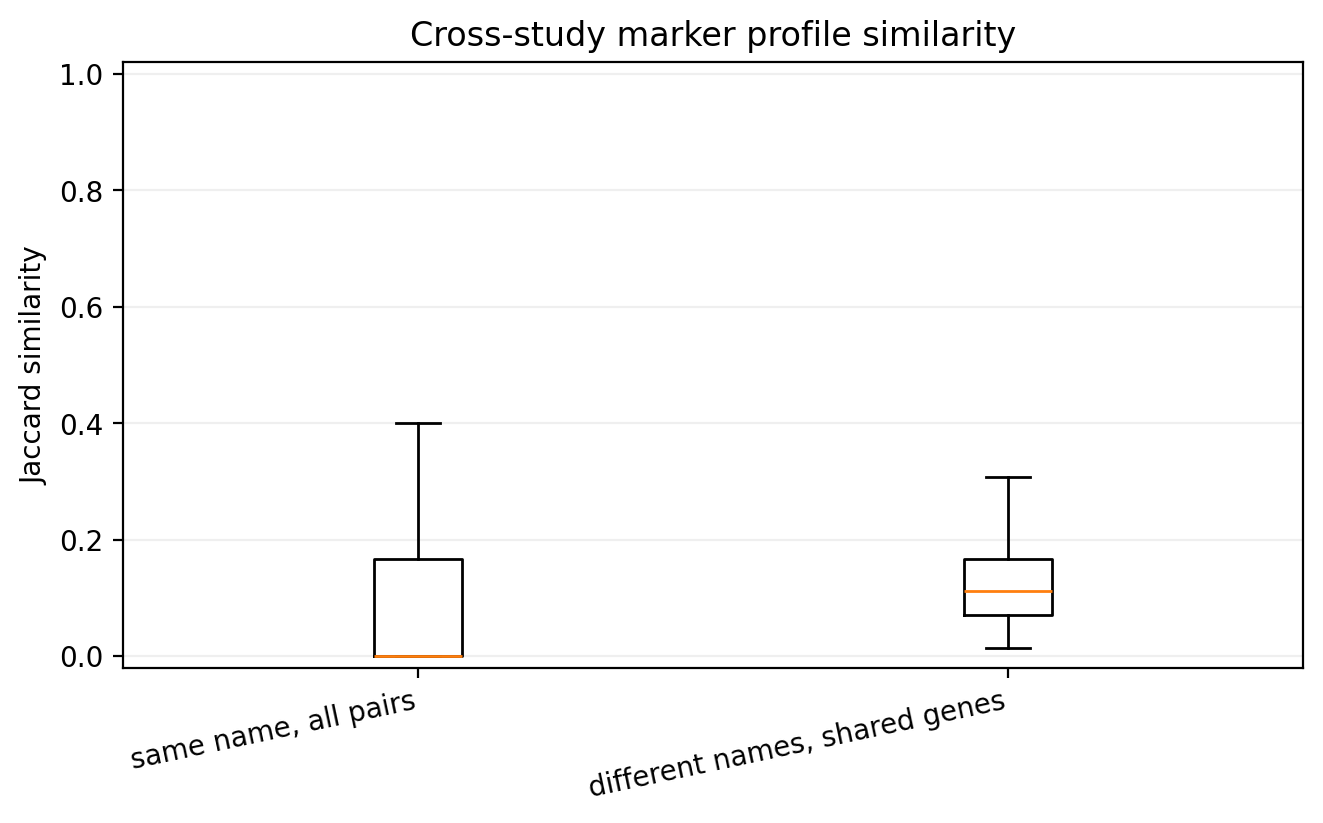

In [8]:
plot_df = pd.DataFrame({
    'comparison': ['different names, shared genes'] * len(pair_df.loc[~pair_df['same_name']]),
    'jaccard': pair_df.loc[~pair_df['same_name'], 'jaccard'].tolist(),
})
plot_df = pd.concat([
    plot_df,
    pd.DataFrame({
        'comparison': ['same name, all pairs'] * len(same_name_df),
        'jaccard': same_name_df['jaccard'].tolist(),
    })
], ignore_index=True)

fig, ax = plt.subplots(figsize=(6.5, 4), constrained_layout=True)
order = ['same name, all pairs', 'different names, shared genes']
box_data = [plot_df.loc[plot_df['comparison'] == label, 'jaccard'] for label in order]
ax.boxplot(box_data, labels=order, showfliers=False)
ax.set_ylabel('Jaccard similarity')
ax.set_title('Cross-study marker profile similarity')
ax.set_ylim(-0.02, 1.02)
ax.grid(axis='y', alpha=0.2)
fig.autofmt_xdate(rotation=12, ha='right')
if WRITE_INTERMEDIATE_FIGURES:
    fig.savefig(PAIRWISE_FIG_PNG, dpi=200, bbox_inches='tight')
    fig.savefig(PAIRWISE_FIG_PDF, bbox_inches='tight')
plt.show()

if WRITE_INTERMEDIATE_FIGURES:
    print(f'Saved figure to {PAIRWISE_FIG_PNG.relative_to(REPO_ROOT)} and {PAIRWISE_FIG_PDF.relative_to(REPO_ROOT)}')

## Different names, similar marker profiles

In [9]:
def gene_names_for_ids(gene_ids):
    return [gene_id_to_name.get(gid, gid) for gid in sorted(gene_ids)]


def enrich_diff_name_pairs(df: pd.DataFrame, limit: int = 25) -> pd.DataFrame:
    rows = []
    for row in df.head(limit).itertuples(index=False):
        key_a = (row.source_corpus_a, row.paper_id_a, row.cell_type_a)
        key_b = (row.source_corpus_b, row.paper_id_b, row.cell_type_b)
        shared_ids = filtered_profiles[key_a] & filtered_profiles[key_b]
        only_a_ids = filtered_profiles[key_a] - filtered_profiles[key_b]
        only_b_ids = filtered_profiles[key_b] - filtered_profiles[key_a]
        rows.append({
            **row._asdict(),
            'shared_gene_names': ';'.join(gene_names_for_ids(shared_ids)),
            'only_a_gene_names': ';'.join(gene_names_for_ids(only_a_ids)),
            'only_b_gene_names': ';'.join(gene_names_for_ids(only_b_ids)),
        })
    return pd.DataFrame(rows)


diff_name_df = pair_df.loc[~pair_df['same_name']].copy()
strong_diff_name_df = diff_name_df.loc[diff_name_df['jaccard'] >= HIGH_JACCARD].copy()
top_diff_name_df = enrich_diff_name_pairs(diff_name_df, limit=40)
maybe_write_table(top_diff_name_df, TOP_DIFF_CACHE)

print(f'Pairs with different names and Jaccard >= {HIGH_JACCARD:.2f}: {len(strong_diff_name_df):,}')
print()

display(top_diff_name_df[
    [
        'source_corpus_a', 'paper_id_a', 'cell_type_a',
        'source_corpus_b', 'paper_id_b', 'cell_type_b',
        'jaccard', 'n_shared', 'shared_gene_names'
    ]
].head(20))

Pairs with different names and Jaccard >= 0.50: 1,867



,source_corpus_a,paper_id_a,cell_type_a,source_corpus_b,paper_id_b,cell_type_b,jaccard,n_shared,shared_gene_names
0,biorxiv,315fa881-726d-1014-9d3d-bbe9b5731a1d,MAIT,hca,0378_10.1101_2022.06.17.496207_92cb140ff3,CD8-GZMK,1.0,5,GZMH;GZMB;GZMK;GZMA;GZMM
1,biorxiv,78211bc7-6c0f-1014-bc42-c103d41718b8,NMSCWANN,hca,0048_10.1038_s41588-022-01243-4_ae2af85553,NMSCHWANN,1.0,5,CD271;SCN7A;CD56;CHD2;L1CAM
2,hca,0090_10.1038_s41586-021-03852-1_eec89a5e36,GOBLET CELL,hca,0481_10.1016_j.immuni.2023.01.002_2da3d3f446,GOBLET,1.0,5,CLCA1;SPDEF;ZG16;MUC2;FCGBP
3,hca,0366_10.1038_s41467-021-22164-6_097f05776f,NAÏVE CD4+ T CELL,hca,0480_10.1038_s41590-019-0398-x_7e5ee33388,CT0B,1.0,5,TCF-1;CCR7;KLF2;LEF1;CD62L
4,hca,0366_10.1038_s41467-021-22164-6_097f05776f,NAÏVE T CELLS,hca,0480_10.1038_s41590-019-0398-x_7e5ee33388,CT0B,1.0,5,TCF-1;CCR7;KLF2;LEF1;CD62L
5,biorxiv,1fa7b83f-6da7-1014-a69d-d257852e8dd1,NAÏVE T CELL,biorxiv,96c0ca44-7598-1014-bd6e-c97aae1f298a,TCM,1.0,4,TCF-1;CCR7;LEF1;CD62L
6,biorxiv,1fa7b83f-6da7-1014-a69d-d257852e8dd1,NAÏVE T CELL,biorxiv,96c0ca44-7598-1014-bd6e-c97aae1f298a,TN,1.0,4,TCF-1;CCR7;LEF1;CD62L
7,biorxiv,1fa7b83f-6da7-1014-a69d-d257852e8dd1,NAÏVE T CELL,biorxiv,e2efdcad-73c4-1014-9c6c-8a89f519fd2d,TREG.1,1.0,4,TCF-1;CCR7;LEF1;CD62L
8,biorxiv,1fa7b83f-6da7-1014-a69d-d257852e8dd1,NAÏVE T CELL,hca,0163_10.1126_sciimmunol.abb4432_91494cf647,NAÏVE/MEMORY,1.0,4,TCF-1;CCR7;LEF1;CD62L
9,biorxiv,96c0ca44-7598-1014-bd6e-c97aae1f298a,TCM,biorxiv,e2efdcad-73c4-1014-9c6c-8a89f519fd2d,TREG.1,1.0,4,TCF-1;CCR7;LEF1;CD62L


## Same name, different marker profiles

In [10]:
def enrich_same_name_pairs(df: pd.DataFrame, limit: int = 25) -> pd.DataFrame:
    rows = []
    for row in df.head(limit).itertuples(index=False):
        key_a = (row.source_corpus_a, row.paper_id_a, row.cell_type)
        key_b = (row.source_corpus_b, row.paper_id_b, row.cell_type)
        shared_ids = filtered_profiles[key_a] & filtered_profiles[key_b]
        only_a_ids = filtered_profiles[key_a] - filtered_profiles[key_b]
        only_b_ids = filtered_profiles[key_b] - filtered_profiles[key_a]
        rows.append({
            **row._asdict(),
            'shared_gene_names': ';'.join(gene_names_for_ids(shared_ids)),
            'only_a_gene_names': ';'.join(gene_names_for_ids(only_a_ids)),
            'only_b_gene_names': ';'.join(gene_names_for_ids(only_b_ids)),
        })
    return pd.DataFrame(rows)


divergent_same_name_df = same_name_df.sort_values(['jaccard', 'n_shared', 'n_union'], ascending=[True, True, False]).copy()
top_same_name_df = enrich_same_name_pairs(divergent_same_name_df, limit=40)
maybe_write_table(top_same_name_df, TOP_SAME_CACHE)

print(f'Same-name pairs with zero overlap: {(same_name_df["n_shared"] == 0).sum():,}')
print()

display(top_same_name_df[
    [
        'cell_type',
        'source_corpus_a', 'paper_id_a',
        'source_corpus_b', 'paper_id_b',
        'jaccard', 'n_shared', 'shared_gene_names',
        'only_a_gene_names', 'only_b_gene_names'
    ]
].head(20))

Same-name pairs with zero overlap: 2,799



,cell_type,source_corpus_a,paper_id_a,source_corpus_b,paper_id_b,jaccard,n_shared,shared_gene_names,only_a_gene_names,only_b_gene_names
0,ENDOTHELIAL CELL,hca,0197_10.3389_fmed.2022.869284_8494fa8c76,hca,0283_10.1161_circulationaha.120.052318_08d58c2441,0.0,0,,SELE;TNFAIP3;CTGF;IRF1;NFKBIZ;LRG1;HSPA1A;ACKR1,CALCRL;PKN2;TIE1;MEF2C;MYL12A;TJP1;CAV2;CAV1;GALNT18;SASH1;AKT3;MYL12B;RAMP 3;PODXL;AFDN;PXDN;RAMP2;STARD13;ETS1;ANXA3;CD29;ROBO4;ERG;ITGA5;CAVIN2;PTK2;LDB2...
1,ENDOTHELIAL CELL,hca,0283_10.1161_circulationaha.120.052318_08d58c2441,hca,0488_10.1073_pnas.1908706116_5dfd6c0233,0.0,0,,CALCRL;PKN2;TIE1;MEF2C;MYL12A;TJP1;CAV2;CAV1;GALNT18;SASH1;AKT3;MYL12B;RAMP 3;PODXL;AFDN;PXDN;RAMP2;STARD13;ETS1;ANXA3;CD29;ROBO4;ERG;ITGA5;CAVIN2;PTK2;LDB2...,LTBP1;SEMA3D;ROBO2;ITGB3
2,ENDOTHELIAL CELL,hca,0047_10.15252_embj.2020107333_a4d0f57474,hca,0283_10.1161_circulationaha.120.052318_08d58c2441,0.0,0,,VWF;CD36;CD34,CALCRL;PKN2;TIE1;MEF2C;MYL12A;TJP1;CAV2;CAV1;GALNT18;SASH1;AKT3;MYL12B;RAMP 3;PODXL;AFDN;PXDN;RAMP2;STARD13;ETS1;ANXA3;CD29;ROBO4;ERG;ITGA5;CAVIN2;PTK2;LDB2...
3,ENDOTHELIAL CELL,hca,0080_10.1126_sciadv.abf1444_8cb053b6ed,hca,0283_10.1161_circulationaha.120.052318_08d58c2441,0.0,0,,VWF;EGFL7;GATA-2,CALCRL;PKN2;TIE1;MEF2C;MYL12A;TJP1;CAV2;CAV1;GALNT18;SASH1;AKT3;MYL12B;RAMP 3;PODXL;AFDN;PXDN;RAMP2;STARD13;ETS1;ANXA3;CD29;ROBO4;ERG;ITGA5;CAVIN2;PTK2;LDB2...
4,ENDOTHELIAL CELL,hca,0198_10.1038_s41467-021-27619-4_12529026b3,hca,0283_10.1161_circulationaha.120.052318_08d58c2441,0.0,0,,PVR;CEACAM1;NECTIN2,CALCRL;PKN2;TIE1;MEF2C;MYL12A;TJP1;CAV2;CAV1;GALNT18;SASH1;AKT3;MYL12B;RAMP 3;PODXL;AFDN;PXDN;RAMP2;STARD13;ETS1;ANXA3;CD29;ROBO4;ERG;ITGA5;CAVIN2;PTK2;LDB2...
5,ENDOTHELIAL CELL,hca,0283_10.1161_circulationaha.120.052318_08d58c2441,hca,0370_10.1038_s41698-022-00251-1_1483c4b104,0.0,0,,CALCRL;PKN2;TIE1;MEF2C;MYL12A;TJP1;CAV2;CAV1;GALNT18;SASH1;AKT3;MYL12B;RAMP 3;PODXL;AFDN;PXDN;RAMP2;STARD13;ETS1;ANXA3;CD29;ROBO4;ERG;ITGA5;CAVIN2;PTK2;LDB2...,PTPRB;KDR;PLVAP
6,ENDOTHELIAL CELL,hca,0283_10.1161_circulationaha.120.052318_08d58c2441,hca,0428_10.1073_pnas.1914143116_42027a0378,0.0,0,,CALCRL;PKN2;TIE1;MEF2C;MYL12A;TJP1;CAV2;CAV1;GALNT18;SASH1;AKT3;MYL12B;RAMP 3;PODXL;AFDN;PXDN;RAMP2;STARD13;ETS1;ANXA3;CD29;ROBO4;ERG;ITGA5;CAVIN2;PTK2;LDB2...,ICAM2;VWF;CD34
7,HSC,biorxiv,dd32f357-70c5-1014-bad0-ccf1b5b647f4,hca,0212_10.1038_s41586-022-04571-x_30a05d7904,0.0,0,,RPL31;RPL21;RPL13A;CRHBP;AVP;RPL27A;RPS17;MEG3,CD41;CD133;RAB27B;HOXA9;RUNX1T1;MECOM;PROCR;CD49D;IGFBP2;EPAS1;MYB;NKX2-3;SPINK2;MEIS2;HEMGN;HMGA2;MSI2;CD90;RUNX1;ACE;GFI1;EMCN;ALDH1;HOXB9;MLLT3;CD34;CD14...
8,FIBROBLAST,biorxiv,e91c125a-709d-1014-bc43-9d192767cd15,hca,0185_10.1038_s41598-019-45842-4_2aeb7a4d45,0.0,0,,IL-32;PLAUR;CNN2;YBX1;TNFRSF1A;PKM;YPEL3;GAPDH;TNFAIP3;SPOP;ZFP36;TXN;THBS1;IGFBP4;RAB13;GUK1;LMNA;S100A11;CITED2;CALR;NPM1;MIF;NME2;MARCKS,DCN;ACTA2;COL1A1;MGP;PDGFR-Β;PDGFR-Α;HGF;CD90;COL3A1;CFD
9,FIBROBLAST,biorxiv,e91c125a-709d-1014-bc43-9d192767cd15,hca,0289_10.1172_jci.insight.93009_72829a2871,0.0,0,,IL-32;PLAUR;CNN2;YBX1;TNFRSF1A;PKM;YPEL3;GAPDH;TNFAIP3;SPOP;ZFP36;TXN;THBS1;IGFBP4;RAB13;GUK1;LMNA;S100A11;CITED2;CALR;NPM1;MIF;NME2;MARCKS,DCN;COL1A1;PRG4;COL1A2;FBN;MFAP4;COL3A1;PLA2G2A;APOD;MFAP5


## Focused immune query: monocyte and macrophage profiles

In [11]:
immune_profile_keys = [key for key in filtered_keys if IMMUNE_PATTERN.search(key[2])]
immune_key_set = set(immune_profile_keys)

immune_pair_df = pair_df.loc[
    pair_df.apply(
        lambda r: (r['source_corpus_a'], r['paper_id_a'], r['cell_type_a']) in immune_key_set
        and (r['source_corpus_b'], r['paper_id_b'], r['cell_type_b']) in immune_key_set,
        axis=1,
    )
].copy()

immune_pair_df = immune_pair_df.sort_values(['jaccard', 'n_shared'], ascending=[False, False])
maybe_write_table(immune_pair_df, IMMUNE_CACHE)

print(f'Immune-focused profiles matching MONOCYTE|MACROPHAGE: {len(immune_profile_keys):,}')
print(f'Immune-focused candidate pairs with >= 1 shared gene: {len(immune_pair_df):,}')
print()

display(immune_pair_df[
    [
        'source_corpus_a', 'paper_id_a', 'cell_type_a',
        'source_corpus_b', 'paper_id_b', 'cell_type_b',
        'jaccard', 'n_shared', 'same_name'
    ]
].head(20))

Immune-focused profiles matching MONOCYTE|MACROPHAGE: 155
Immune-focused candidate pairs with >= 1 shared gene: 1,800



,source_corpus_a,paper_id_a,cell_type_a,source_corpus_b,paper_id_b,cell_type_b,jaccard,n_shared,same_name
43598,biorxiv,c8264099-6fc3-1014-9d27-9ae05a0c1d33,MONOCYTE,biorxiv,f787a6d9-6ce3-1014-a3f6-a662a1333571,MONOCYTES,1.00,3,False
42231,biorxiv,c245f005-7ab6-1014-adbd-b49bd8bfffbc,MONOCYTE,biorxiv,e6e04172-6c15-1014-9229-c57ac33d21f6,MONOCYTE,0.75,3,True
43592,biorxiv,c8264099-6fc3-1014-9d27-9ae05a0c1d33,MONOCYTE,biorxiv,e6e04172-6c15-1014-9229-c57ac33d21f6,MONOCYTE,0.75,3,True
43616,biorxiv,c8264099-6fc3-1014-9d27-9ae05a0c1d33,MONOCYTE,hca,0109_10.7554_elife.91792.1_056dda27be,INFLAMMATORY MONOCYTES,0.75,3,False
51570,biorxiv,e6e04172-6c15-1014-9229-c57ac33d21f6,MONOCYTE,biorxiv,f787a6d9-6ce3-1014-a3f6-a662a1333571,MONOCYTES,0.75,3,False
51618,biorxiv,e6e04172-6c15-1014-9229-c57ac33d21f6,MONOCYTE,hca,0284_10.1002_hep4.1854_fe09f5fe1e,INFLAMMATORY MACROPHAGES,0.75,3,False
53630,biorxiv,f3be1d12-72db-1014-a9a0-ac8d78e3151e,MONOCYTE-DERIVED CELL,hca,0414_10.1186_s13059-020-02210-0_30c1533a3e,MONOCYTE,0.75,3,False
54540,biorxiv,f787a6d9-6ce3-1014-a3f6-a662a1333571,MONOCYTES,hca,0109_10.7554_elife.91792.1_056dda27be,INFLAMMATORY MONOCYTES,0.75,3,False
104267,hca,0349_10.1038_s41467-023-36296-4_67ae3c1e19,C1QC+ MACROPHAGE,hca,0365_10.3389_fendo.2022.874915_81de77d539,MACROPHAGE,0.75,3,False
107096,hca,0365_10.3389_fendo.2022.874915_81de77d539,MACROPHAGE,hca,0481_10.1016_j.immuni.2023.01.002_2da3d3f446,MACROPHAGE,0.75,3,True


## Figure 4 draft: cross-study unification

This draft figure summarizes the utility of machine-readable marker records for cross-study comparison. It moves from extracted marker claims, to paper-level name/marker overlap, to marker-neighbor edges that can be decomposed into shared biological programs and context-specific differences.

### Analysis assumptions

- The canonical BioRxiv and HCA cohorts are restricted to human records with a mapped Ensembl gene ID and full text verification (`all_verified == True`).
- Human-curated benchmark rows are summarized separately because they were curated by a human annotator and do not have the same `all_verified` field as LLM-extracted BioRxiv/HCA records.
- Duplicate marker records are collapsed within `(source_corpus, paper_id, cell type name, Ensembl gene ID)` before profiles are built.
- Cell type names are compared by normalized exact string equality. This treats spelling, pluralization, abbreviations, and ontology-equivalent names as different unless their strings match after normalization.
- Paper-level overlap compares the set of cell type names and the set of marker genes reported in each paper. It intentionally ignores which marker belongs to which cell type.
- Cell-type profile comparisons use marker-gene Jaccard similarity on `(paper, cell type)` profiles with at least three markers.
- Panel C shows the distribution of top cross-paper marker-profile Jaccard values among profiles with at least one shared marker gene.
- Panel D treats cross-paper marker-profile comparison as a nearest-neighbor retrieval problem.
- In Panel D, each `(paper, cell type)` profile is assigned its top cross-paper marker-profile neighbor among profiles with at least one shared marker gene.
- If multiple top-scoring neighbors are tied and include both same-name and different-name labels, the profile is counted as a mixed top tie.
- The edge-decomposition review is a manual biological audit over representative marker-neighbor pairs, not a corpus-wide automated classifier.
- SKOS relations in the review layer are directional from the Paper 1 label to the Paper 2 label.
- Shared markers are treated as evidence for a shared marker program, not proof of cell-type equivalence.
- Unique markers and manuscript context are used to interpret whether a relation reflects identity, hierarchy, state, context, or an unresolved case.
- Panel B is a paper-level 2x2 summary. A paper pair is counted as sharing labels if the two papers have at least one exact normalized cell type name in common, and as sharing markers if they have at least one Ensembl marker gene ID in common. This deliberately ignores which marker belongs to which cell type; Panels C-E address profile-level relationships.


### Paper-pair name and marker overlap

For each paper, we collect the set of reported cell type names and the set of reported marker genes. We then compare every off-diagonal paper pair using Jaccard similarity for names and marker genes separately.

In [12]:
paper_groups = canonical_df.groupby(['source_corpus', 'paper_id', 'paper_key'], sort=True)

paper_rows = []
for (source_corpus, paper_id, paper_key), group in paper_groups:
    paper_rows.append({
        'source_corpus': source_corpus,
        'paper_id': paper_id,
        'paper_key': paper_key,
        'cell_type_names': set(group['group_name_norm']),
        'marker_genes': set(group['feature_id']),
        'n_cell_type_names': group['group_name_norm'].nunique(),
        'n_marker_genes': group['feature_id'].nunique(),
        'n_records': len(group),
    })

paper_sets_df = pd.DataFrame(paper_rows)

paper_pair_rows = []
for i in range(len(paper_sets_df)):
    names_i = paper_sets_df.at[i, 'cell_type_names']
    genes_i = paper_sets_df.at[i, 'marker_genes']
    for j in range(i + 1, len(paper_sets_df)):
        names_j = paper_sets_df.at[j, 'cell_type_names']
        genes_j = paper_sets_df.at[j, 'marker_genes']

        name_union = names_i | names_j
        gene_union = genes_i | genes_j
        name_jaccard = len(names_i & names_j) / len(name_union) if name_union else 0.0
        gene_jaccard = len(genes_i & genes_j) / len(gene_union) if gene_union else 0.0

        paper_pair_rows.append({
            'source_corpus_a': paper_sets_df.at[i, 'source_corpus'],
            'source_corpus_b': paper_sets_df.at[j, 'source_corpus'],
            'paper_id_a': paper_sets_df.at[i, 'paper_id'],
            'paper_id_b': paper_sets_df.at[j, 'paper_id'],
            'paper_key_a': paper_sets_df.at[i, 'paper_key'],
            'paper_key_b': paper_sets_df.at[j, 'paper_key'],
            'name_jaccard': name_jaccard,
            'marker_jaccard': gene_jaccard,
            'shared_names': len(names_i & names_j),
            'shared_genes': len(genes_i & genes_j),
            'corpus_pair': '__'.join(sorted([
                paper_sets_df.at[i, 'source_corpus'],
                paper_sets_df.at[j, 'source_corpus'],
            ])),
        })

paper_pair_df = pd.DataFrame(paper_pair_rows)
PAPER_PAIR_CACHE = RESULTS_DIR / 'cross_study_paper_pair_jaccard.tsv'
maybe_write_table(paper_pair_df, PAPER_PAIR_CACHE)

print(f'Paper pairs: {len(paper_pair_df):,}')
print(f'Spearman rho, names vs markers: {paper_pair_df[["name_jaccard", "marker_jaccard"]].corr(method="spearman").iloc[0, 1]:.3f}')
display(
    paper_pair_df.groupby('corpus_pair')
    .agg(
        paper_pairs=('marker_jaccard', 'size'),
        median_name_jaccard=('name_jaccard', 'median'),
        median_marker_jaccard=('marker_jaccard', 'median'),
        pairs_with_shared_names=('shared_names', lambda s: int((s > 0).sum())),
        pairs_with_shared_genes=('shared_genes', lambda s: int((s > 0).sum())),
    )
)

Paper pairs: 286,903
Spearman rho, names vs markers: 0.279


,paper_pairs,median_name_jaccard,median_marker_jaccard,pairs_with_shared_names,pairs_with_shared_genes
corpus_pair,,,,,
biorxiv__biorxiv,55278,0.0,0.0,2518,8525
biorxiv__hca,141525,0.0,0.0,9212,34172
hca__hca,90100,0.0,0.0,9259,34998


### Corpus summary and fixed example matrices

Panel A summarizes the analysis-ready records from the human-curated benchmark, BioRxiv, and HCA corpora. The fixed example matrices below are retained for supplementary inspection, but the main Figure 4 now uses the reviewed edge-decomposition layer for its final panels.

In [13]:
benchmark_records = []
for path in sorted((REPO_ROOT / 'data').glob('*/evidence_human/extracted.json')):
    dataset = path.parent.parent.name
    with open(path) as f:
        markers = json.load(f)
    for marker in markers:
        benchmark_records.append({
            'source_corpus': 'human curated',
            'paper_id': dataset,
            'paper_key': f'human curated:{dataset}',
            'organism': clean_text(marker.get('organism')).lower(),
            'group_name_norm': clean_upper(marker.get('group_name')),
            'feature_name_norm': clean_upper(marker.get('feature_name')),
            'feature_id': clean_text(marker.get('feature_id')),
        })

benchmark_df = pd.DataFrame(benchmark_records)
benchmark_canonical_df = benchmark_df.loc[
    (benchmark_df['organism'] == 'homo_sapiens')
    & benchmark_df['feature_id'].ne('')
    & benchmark_df['group_name_norm'].ne('')
].copy()
benchmark_canonical_df = benchmark_canonical_df.drop_duplicates(
    subset=['paper_id', 'group_name_norm', 'feature_id'],
    keep='first'
)

benchmark_profiles = benchmark_canonical_df.groupby(['paper_id', 'group_name_norm'])['feature_id'].nunique()
cross_study_profiles = canonical_df.groupby(['source_corpus', 'paper_id', 'group_name_norm'])['feature_id'].nunique()

corpus_summary_rows = []
corpus_summary_rows.append({
    'Corpus': 'Human curated benchmark',
    'Studies / papers': benchmark_df['paper_id'].nunique(),
    'Raw records': len(benchmark_df),
    'Analysis-ready records': len(benchmark_canonical_df),
    'Profiles (>=3 genes)': int((benchmark_profiles >= MIN_MARKERS).sum()),
    'Cell type names': benchmark_canonical_df['group_name_norm'].nunique(),
    'Gene IDs': benchmark_canonical_df['feature_id'].nunique(),
})

for corpus in ['biorxiv', 'hca']:
    raw_subset = records_df.loc[records_df['source_corpus'] == corpus]
    canonical_subset = canonical_df.loc[canonical_df['source_corpus'] == corpus]
    profile_subset = cross_study_profiles.loc[corpus]
    corpus_summary_rows.append({
        'Corpus': 'BioRxiv preprints' if corpus == 'biorxiv' else 'HCA publications',
        'Studies / papers': raw_subset['paper_key'].nunique(),
        'Raw records': len(raw_subset),
        'Analysis-ready records': len(canonical_subset),
        'Profiles (>=3 genes)': int((profile_subset >= MIN_MARKERS).sum()),
        'Cell type names': canonical_subset['group_name_norm'].nunique(),
        'Gene IDs': canonical_subset['feature_id'].nunique(),
    })

corpus_summary_df = pd.DataFrame(corpus_summary_rows)
FIGURE_SUMMARY_TABLE = RESULTS_DIR / 'cross_study_figure4_corpus_summary.tsv'
maybe_write_table(corpus_summary_df, FIGURE_SUMMARY_TABLE)
display(corpus_summary_df)


def gene_id_from_label(label):
    hits = canonical_df.loc[canonical_df['feature_name_norm'] == label, 'feature_id'].dropna().unique()
    if len(hits) == 0:
        return None
    return hits[0]

# Use Ensembl IDs for the matrices and hand-set display labels for readability.
pc_marker_columns = [
    ('CD19', gene_id_from_label('CD19')),
    ('CD27', gene_id_from_label('CD27')),
    ('CD38', gene_id_from_label('CD38')),
    ('CD138', gene_id_from_label('CD138')),
    ('PRDM1', gene_id_from_label('PRDM1')),
    ('IRF4', gene_id_from_label('IRF4')),
    ('XBP1', gene_id_from_label('XBP1')),
    ('MZB1', gene_id_from_label('MZB1')),
    ('TNFRSF17', gene_id_from_label('TNFRSF17')),
]
pc_marker_columns = [(label, gene_id) for label, gene_id in pc_marker_columns if gene_id]

pc_profiles = [
    ('biorxiv', '653bfd04-6cbf-1014-864b-c74846f5cd96', 'PC', 'PC\nBioRxiv'),
    ('biorxiv', '9c7f8281-6c21-1014-a6df-b6c543b29cb8', 'ASC', 'ASC\nBioRxiv'),
    ('biorxiv', '9a5466f2-6c88-1014-bd5d-ff8513618027', 'ANTIBODY-SECRETING CELL', 'antibody-secreting\nBioRxiv'),
    ('hca', '0073_10.1016_j.isci.2021.102482_6ff6d432ab', 'PLASMABLAST', 'plasmablast\nHCA'),
    ('hca', '0113_10.1101_2021.04.28.441762_c83625bbe4', 'PLASMA CELL', 'plasma cell\nHCA'),
    ('hca', '0207_10.1016_j.immuni.2020.11.017_b182001861', 'PLASMABLAST', 'plasmablast\nHCA'),
]

mono_marker_columns = [
    ('CD14', gene_id_from_label('CD14')),
    ('S100A8', gene_id_from_label('S100A8')),
    ('S100A9', gene_id_from_label('S100A9')),
    ('S100A12', gene_id_from_label('S100A12')),
    ('VCAN', gene_id_from_label('VCAN')),
    ('NAMPT', gene_id_from_label('NAMPT')),
    ('IL4R', gene_id_from_label('IL4R')),
    ('CXCR1', gene_id_from_label('CXCR1')),
    ('IL1R1', gene_id_from_label('IL1R1')),
    ('IL10RA', gene_id_from_label('IL10RA')),
    ('IFNGR1', gene_id_from_label('IFNGR1')),
    ('IFNGR2', gene_id_from_label('IFNGR2')),
    ('HLA-DRB1', gene_id_from_label('HLA-DRB1')),
    ('HLA-DQA1', gene_id_from_label('HLA-DQA1')),
    ('TNFRSF1B', gene_id_from_label('TNFRSF1B')),
]
mono_marker_columns = [(label, gene_id) for label, gene_id in mono_marker_columns if gene_id]

mono_profiles = [
    ('biorxiv', 'c8264099-6fc3-1014-9d27-9ae05a0c1d33', 'MONOCYTE', 'MONOCYTE\nBioRxiv'),
    ('hca', '0414_10.1186_s13059-020-02210-0_30c1533a3e', 'MONOCYTE', 'MONOCYTE\nHCA'),
    ('hca', '0364_10.1161_circulationaha.120.046528_00aa2deb4c', 'MONOCYTE', 'MONOCYTE\nHCA'),
    ('hca', '0488_10.1073_pnas.1908706116_5dfd6c0233', 'MONOCYTE', 'MONOCYTE\nHCA'),
]

pc_matrix = []
for source_corpus, paper_id, cell_type, label in pc_profiles:
    genes = set(canonical_df.loc[
        (canonical_df['source_corpus'] == source_corpus)
        & (canonical_df['paper_id'] == paper_id)
        & (canonical_df['group_name_norm'] == cell_type),
        'feature_id'
    ])
    pc_matrix.append([int(gene_id in genes) for _, gene_id in pc_marker_columns])
pc_matrix = np.array(pc_matrix)

mono_matrix = []
for source_corpus, paper_id, cell_type, label in mono_profiles:
    genes = set(canonical_df.loc[
        (canonical_df['source_corpus'] == source_corpus)
        & (canonical_df['paper_id'] == paper_id)
        & (canonical_df['group_name_norm'] == cell_type),
        'feature_id'
    ])
    mono_matrix.append([int(gene_id in genes) for _, gene_id in mono_marker_columns])
mono_matrix = np.array(mono_matrix)

,Corpus,Studies / papers,Raw records,Analysis-ready records,Profiles (>=3 genes),Cell type names,Gene IDs
0,Human curated benchmark,7,2528,1555,149,168,620
1,BioRxiv preprints,421,12501,7153,954,1876,2353
2,HCA publications,434,20120,16986,2397,3640,3603


### Edge-decomposition review layer

For reviewed marker-neighbor edges, we decompose each relationship into two parts: shared markers explain why the graph connects two labels, and unique markers plus manuscript context explain why the labels should be merged, mapped hierarchically, related by state, kept context-specific, or flagged for follow-up.

In [14]:

EDGE_REVIEW_CACHE = RESULTS_DIR / 'cross_study_context_comparison_review_anchored.tsv'
EDGE_DECOMPOSITION_CACHE = RESULTS_DIR / 'cross_study_edge_decomposition_review.tsv'
EDGE_SKOS_SUMMARY_CACHE = RESULTS_DIR / 'cross_study_edge_skos_summary.tsv'
EDGE_DRIVER_SUMMARY_CACHE = RESULTS_DIR / 'cross_study_edge_driver_summary.tsv'
EDGE_DRIVER_EVIDENCE_CACHE = RESULTS_DIR / 'cross_study_edge_driver_evidence.tsv'

edge_review_df = pd.read_csv(EDGE_REVIEW_CACHE, sep='\t').fillna('')
edge_review_df['driver_items'] = edge_review_df['driver_evidence'].map(lambda value: json.loads(value) if value else [])
edge_review_df['has_followup_flag'] = edge_review_df['followup_flag'].ne('')

edge_decomposition_cols = [
    'cell_type_1', 'reviewed_context_1', 'markers_1',
    'cell_type_2', 'reviewed_context_2', 'markers_2',
    'shared_markers', 'unique_markers_1', 'unique_markers_2', 'jaccard',
    'skos_relation_from_1_to_2', 'skos_evidence', 'biological_drivers',
    'marker_relationship_summary', 'pairwise_assessment', 'followup_flag',
    'paper_1_title', 'paper_2_title', 'manuscript_1', 'manuscript_2',
    'evidence_line_1', 'evidence_line_2',
]
edge_decomposition_df = edge_review_df[edge_decomposition_cols].copy()
edge_decomposition_df = edge_decomposition_df.rename(columns={
    'reviewed_context_1': 'context_1',
    'reviewed_context_2': 'context_2',
    'marker_relationship_summary': 'shared_marker_interpretation',
})
maybe_write_table(edge_decomposition_df, EDGE_DECOMPOSITION_CACHE)

skos_order = ['exactMatch', 'closeMatch', 'broadMatch', 'narrowMatch', 'relatedMatch', 'unresolved']
edge_skos_summary_df = (
    edge_review_df['skos_relation_from_1_to_2']
    .value_counts()
    .reindex(skos_order, fill_value=0)
    .rename_axis('skos_relation_from_1_to_2')
    .reset_index(name='edges')
)
edge_skos_summary_df['fraction'] = edge_skos_summary_df['edges'] / len(edge_review_df)
maybe_write_table(edge_skos_summary_df, EDGE_SKOS_SUMMARY_CACHE)

driver_rows = []
for row in edge_review_df.itertuples(index=True):
    for item in row.driver_items:
        driver_rows.append({
            'edge_index': row.Index,
            'cell_type_1': row.cell_type_1,
            'cell_type_2': row.cell_type_2,
            'skos_relation_from_1_to_2': row.skos_relation_from_1_to_2,
            'driver': item.get('driver', ''),
            'evidence_type': item.get('evidence_type', ''),
            'evidence': item.get('evidence', ''),
        })
edge_driver_evidence_df = pd.DataFrame(driver_rows)
maybe_write_table(edge_driver_evidence_df, EDGE_DRIVER_EVIDENCE_CACHE)

edge_driver_summary_df = (
    edge_driver_evidence_df
    .groupby('driver', as_index=False)
    .agg(
        edges=('edge_index', 'nunique'),
        evidence_items=('edge_index', 'size'),
    )
    .sort_values(['edges', 'driver'], ascending=[False, True])
)
edge_driver_summary_df['fraction_of_reviewed_edges'] = edge_driver_summary_df['edges'] / len(edge_review_df)
maybe_write_table(edge_driver_summary_df, EDGE_DRIVER_SUMMARY_CACHE)

print(f'Reviewed edges: {len(edge_review_df):,}')
print(f'Flagged for follow-up: {edge_review_df["has_followup_flag"].sum():,}')

display(edge_skos_summary_df)
display(edge_driver_summary_df)
display(
    edge_decomposition_df[[
        'cell_type_1', 'context_1', 'cell_type_2', 'context_2',
        'shared_markers', 'unique_markers_1', 'unique_markers_2',
        'skos_relation_from_1_to_2', 'biological_drivers',
        'shared_marker_interpretation',
    ]].head(12)
)


Reviewed edges: 55
Flagged for follow-up: 3


,skos_relation_from_1_to_2,edges,fraction
0,exactMatch,3,0.054545
1,closeMatch,8,0.145455
2,broadMatch,14,0.254545
3,narrowMatch,4,0.072727
4,relatedMatch,24,0.436364
5,unresolved,2,0.036364


,driver,edges,evidence_items,fraction_of_reviewed_edges
7,lineage,46,46,0.836364
5,functional_state,41,41,0.745455
3,disease_context,25,25,0.454545
6,granularity,25,25,0.454545
1,anatomical_context,20,20,0.363636
0,alias,8,8,0.145455
2,developmental_context,8,8,0.145455
9,technical_context,7,7,0.127273
4,extraction_issue,3,3,0.054545
8,sample_context,3,3,0.054545


,cell_type_1,context_1,cell_type_2,context_2,shared_markers,unique_markers_1,unique_markers_2,skos_relation_from_1_to_2,biological_drivers,shared_marker_interpretation
0,MAIT,immune cytotoxicity atlas,CD8-GZMK,cystic-fibrosis bronchoalveolar lavage,GZMH;GZMB;GZMK;GZMA;GZMM,,,unresolved,functional_state;lineage;sample_context;extraction_issue,Granzyme markers define a shared cytotoxic program; extraction should be checked because the MAIT text negates two extracted genes.
1,MONOCYTE,ambient RNA/decontamination benchmark,INFLAMMATORY MACROPHAGES,human liver single-cell/spatial atlas,LYZ;S100A8;S100A9,CD14,,relatedMatch,functional_state;lineage;anatomical_context;technical_context,LYZ/S100A8/S100A9 are inflammatory myeloid markers; CD14 is unique to the monocyte profile.
2,CYTOTOXIC T CELL,liver tumor microenvironment,CD8 MEMORY BLOOD,CNS/blood T-cell profiling,NKG7;GZMK;CCL5,,S100A4,relatedMatch,functional_state;lineage;anatomical_context;disease_context;sample_context,NKG7/GZMK/CCL5 connect cytotoxicity with memory CD8 annotation; S100A4 adds memory context.
3,RECIPIENT T CELL,rejecting kidney transplant recipient/rejecting cells,CYTOTOXIC,melanoma anti-PD1 CD8 states,GZMB;GNLY;PRF1,NKG7,,relatedMatch,functional_state;sample_context;disease_context,GNLY/GZMB/PRF1 capture cytotoxic effector function across study-specific labels.
4,LN T CELL,lupus nephritis kidney/skin comparison,CYTOTOXIC,melanoma CD8-state analysis,GZMB;GNLY;PRF1,GZMH,,relatedMatch,functional_state;anatomical_context;disease_context,GZMB/GNLY/PRF1 link LN T cells to a cytotoxic program; GZMH is unique to the LN context.
5,CONTRACTILE SMCS,smooth muscle mechanical-stretch study,MES3,liver mesenchymal heterogeneity atlas,MYL9;ACTA2;TAGLN,,,closeMatch,functional_state;granularity;anatomical_context,ACTA2/TAGLN/MYL9 mark contractility; naming difference likely reflects cluster naming and tissue context.
6,KERA A,ischemic limb repair/diabetes study,EPIDERMIS,psoriasis skin atlas,KRT1;KRT10;KRT14,,,closeMatch,alias;granularity;anatomical_context;disease_context,KRT1/KRT10/KRT14 support epidermal/keratinocyte identity.
7,PERICYTE,tumor immune landscape,VASCULAR SMOOTH MUSCLE CELL,intestinal niche developmental atlas,ACTA2;RGS5;TAGLN,,,relatedMatch,lineage;granularity;anatomical_context;developmental_context,ACTA2/TAGLN/RGS5 mark mural/contractile cells and blur pericyte-SMC boundaries.
8,PC,salivary gland dysfunction study,VASCULAR MURAL CELL,glioblastoma endothelial-cell study,NOTCH3;PDGFRB;RGS5,,,broadMatch,alias;granularity;lineage;anatomical_context;disease_context,NOTCH3/PDGFRB/RGS5 identify pericyte/mural cells.
9,SMOOTH MUSCLE CELL,endometrium menstrual-cycle atlas,EMSC,cultured endometrial stromal cells,MCAM;SUSD2;PDGFRB,,,relatedMatch,functional_state;lineage;anatomical_context;technical_context,MCAM/SUSD2/PDGFRB point to endometrial mesenchymal stem/stromal identity.


### Multi-panel draft figure

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

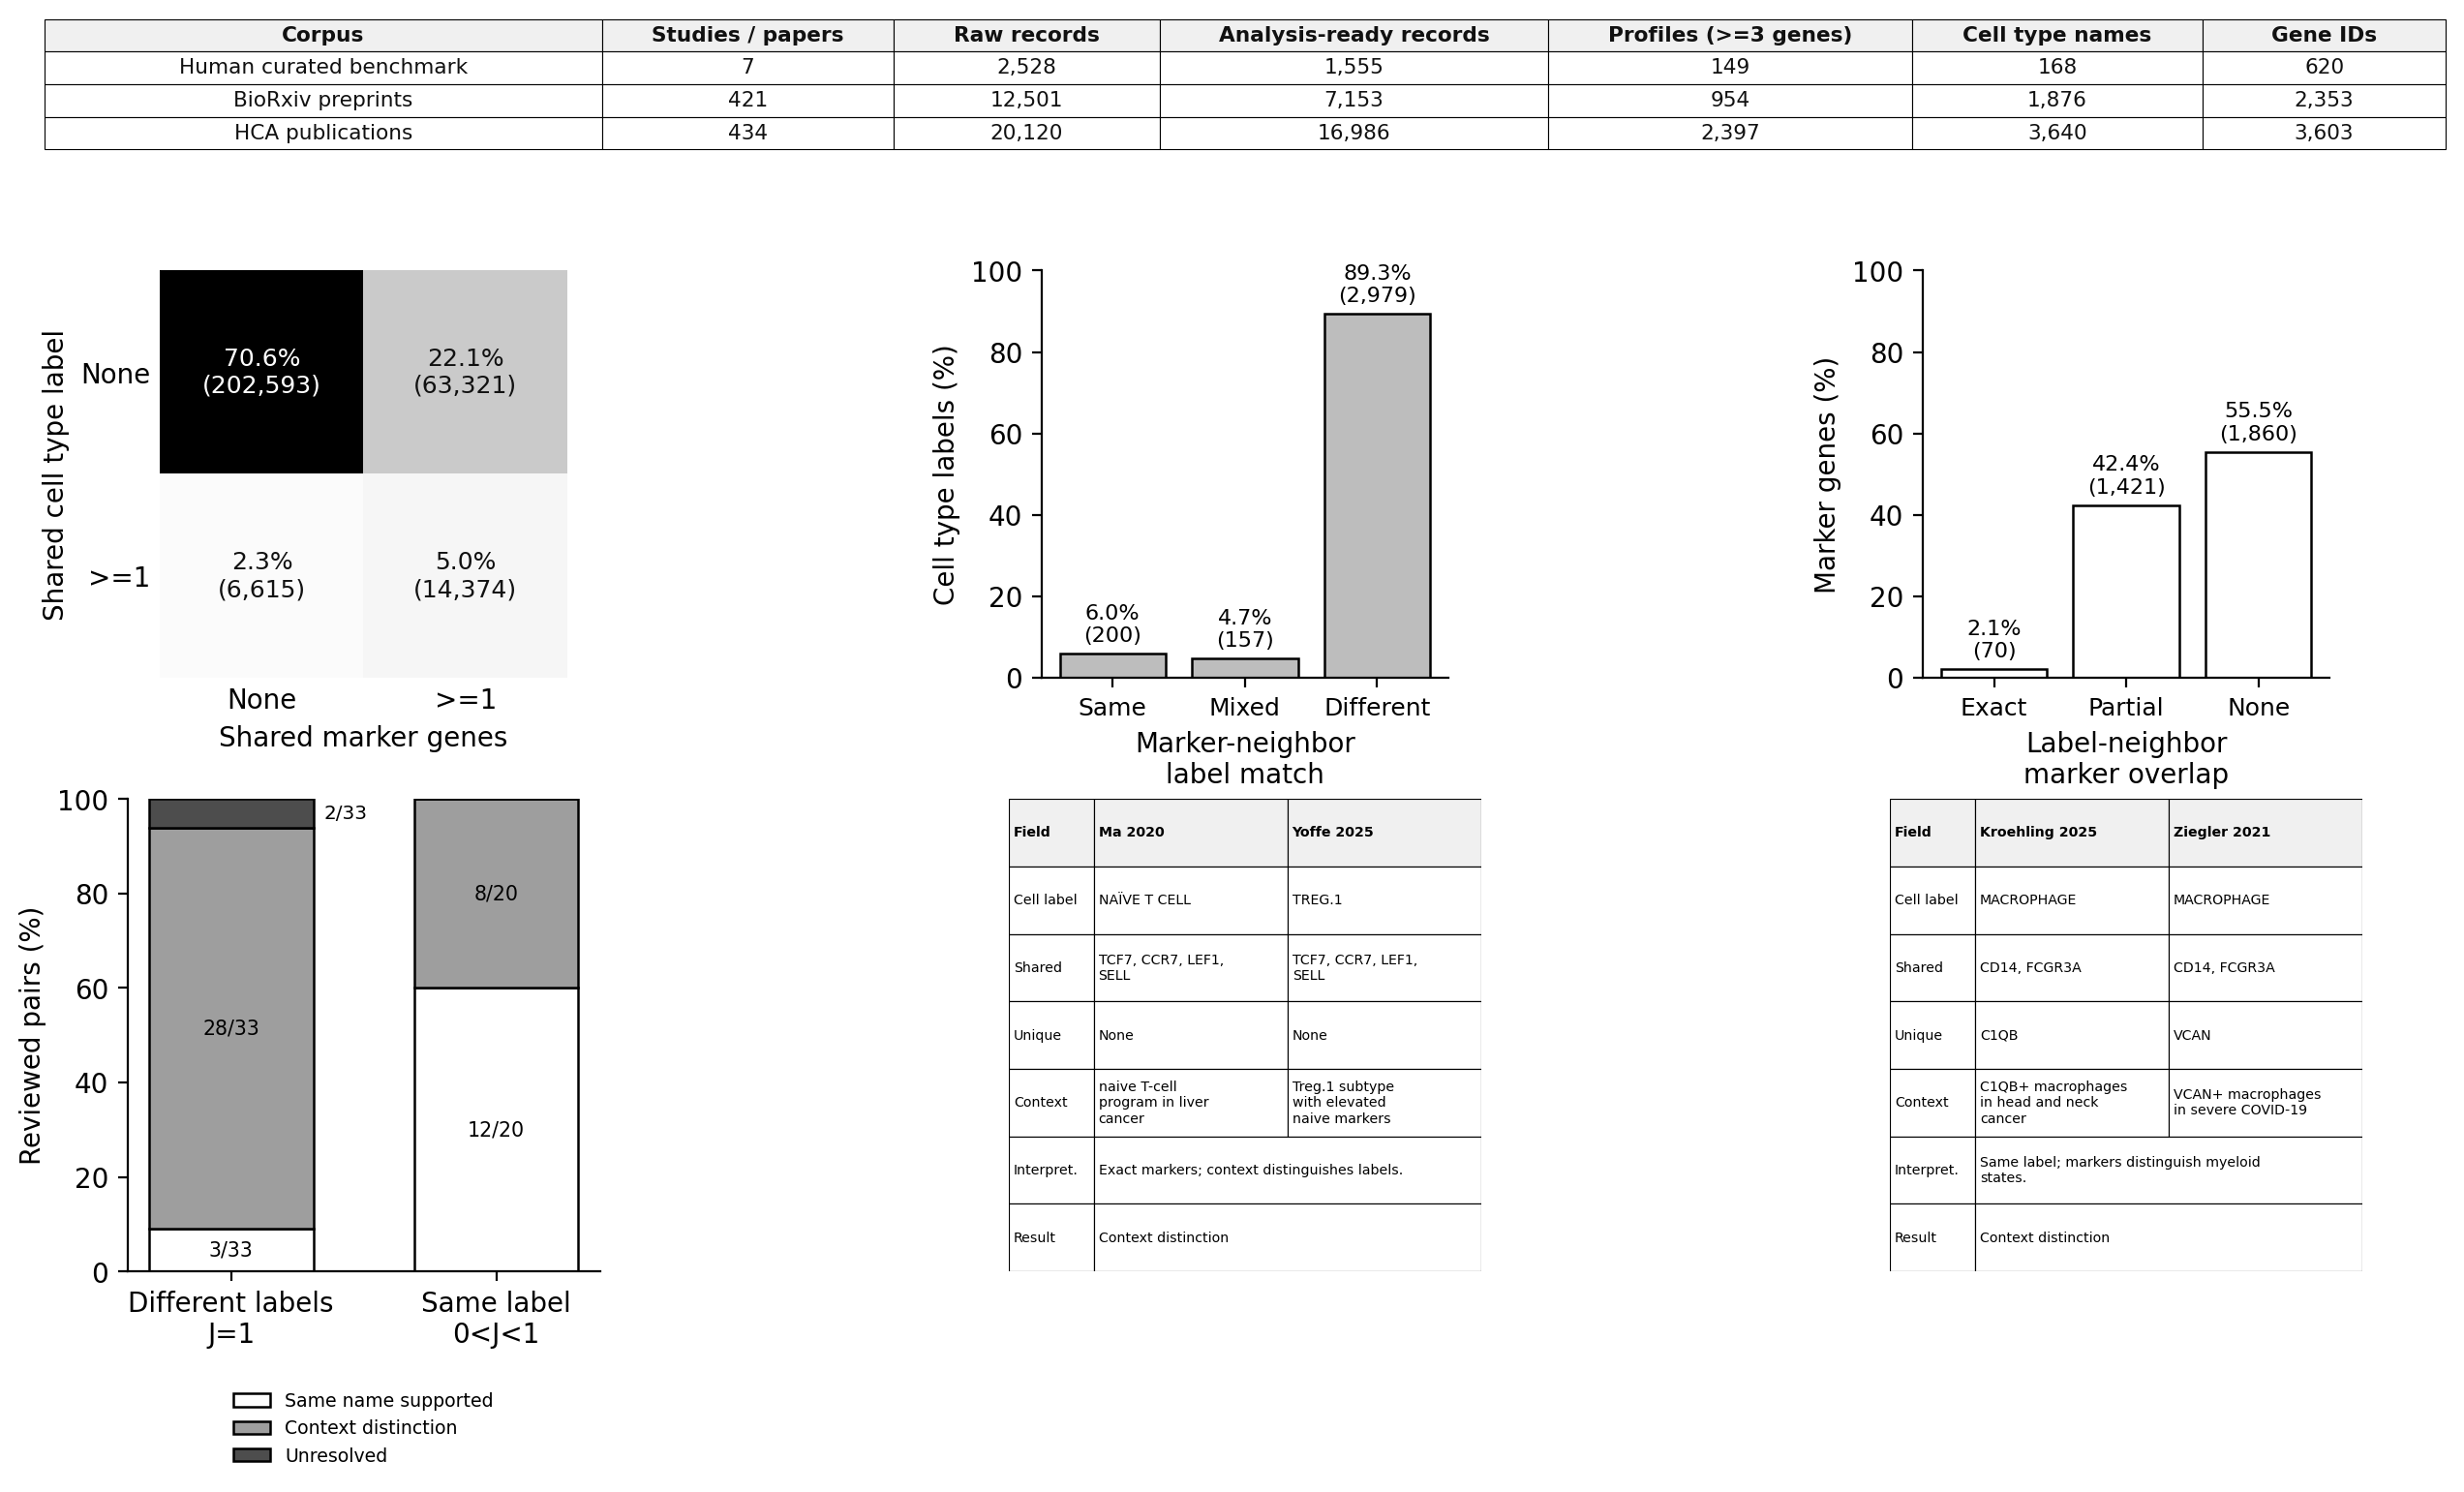

Saved figure to analysis/figures/fig_cross_study_unification.png
Saved figure to analysis/figures/fig_cross_study_unification.pdf


In [15]:

def nd(arr):
    return np.asarray(arr).reshape(-1)


def yex(ax):
    lims = [
        np.min([ax.get_xlim(), ax.get_ylim()]),
        np.max([ax.get_xlim(), ax.get_ylim()]),
    ]
    ax.plot(lims, lims, c='k', alpha=0.75, zorder=0, linewidth=1)
    ax.set(xlim=lims, ylim=lims)
    ax.set_box_aspect(1)
    return ax

FIG4_PNG = FIGURES_DIR / 'fig_cross_study_unification.png'
FIG4_PDF = FIGURES_DIR / 'fig_cross_study_unification.pdf'
NEAREST_JACCARD_SUMMARY_CACHE = RESULTS_DIR / 'cross_study_nearest_neighbor_jaccard_summary.tsv'

same_name_values = same_name_df['jaccard'].to_numpy()
different_name_candidate_values = pair_df.loc[~pair_df['same_name'], 'jaccard'].to_numpy()
paper_rho = paper_pair_df[['name_jaccard', 'marker_jaccard']].corr(method='spearman').iloc[0, 1]
mean_name_jaccard = paper_pair_df['name_jaccard'].mean()
mean_marker_jaccard = paper_pair_df['marker_jaccard'].mean()

neighbor_a = pair_df.rename(columns={
    'source_corpus_a': 'source_corpus',
    'paper_id_a': 'paper_id',
    'paper_key_a': 'paper_key',
    'cell_type_a': 'cell_type',
    'source_corpus_b': 'neighbor_source_corpus',
    'paper_id_b': 'neighbor_paper_id',
    'paper_key_b': 'neighbor_paper_key',
    'cell_type_b': 'neighbor_cell_type',
})
neighbor_b = pair_df.rename(columns={
    'source_corpus_b': 'source_corpus',
    'paper_id_b': 'paper_id',
    'paper_key_b': 'paper_key',
    'cell_type_b': 'cell_type',
    'source_corpus_a': 'neighbor_source_corpus',
    'paper_id_a': 'neighbor_paper_id',
    'paper_key_a': 'neighbor_paper_key',
    'cell_type_a': 'neighbor_cell_type',
})
neighbor_cols = [
    'source_corpus', 'paper_id', 'paper_key', 'cell_type',
    'neighbor_source_corpus', 'neighbor_paper_id', 'neighbor_paper_key', 'neighbor_cell_type',
    'jaccard', 'n_shared', 'same_name'
]
neighbor_candidate_df = pd.concat([neighbor_a[neighbor_cols], neighbor_b[neighbor_cols]], ignore_index=True)
neighbor_candidate_df['top_jaccard'] = neighbor_candidate_df.groupby(
    ['source_corpus', 'paper_id', 'cell_type']
)['jaccard'].transform('max')
top_neighbor_ties_df = neighbor_candidate_df.loc[
    neighbor_candidate_df['jaccard'] == neighbor_candidate_df['top_jaccard']
].copy()
nearest_neighbor_df = (
    top_neighbor_ties_df
    .groupby(['source_corpus', 'paper_id', 'paper_key', 'cell_type'], sort=False)
    .agg(
        top_jaccard=('jaccard', 'max'),
        top_neighbor_count=('jaccard', 'size'),
        n_same_name_top=('same_name', 'sum'),
    )
    .reset_index()
)
nearest_neighbor_df['n_different_name_top'] = nearest_neighbor_df['top_neighbor_count'] - nearest_neighbor_df['n_same_name_top']
nearest_neighbor_df['nearest_name_relation'] = np.select(
    [
        (nearest_neighbor_df['n_same_name_top'] > 0) & (nearest_neighbor_df['n_different_name_top'] == 0),
        (nearest_neighbor_df['n_same_name_top'] == 0) & (nearest_neighbor_df['n_different_name_top'] > 0),
    ],
    ['Same label', 'Different label'],
    default='Mixed top tie',
)
maybe_write_table(nearest_neighbor_df, NEAREST_NEIGHBOR_CACHE)
nearest_jaccard_values = nearest_neighbor_df['top_jaccard'].to_numpy()
nearest_jaccard_summary_df = pd.DataFrame([{
    'profiles': len(nearest_neighbor_df),
    'mean_top_jaccard': float(np.mean(nearest_jaccard_values)),
    'median_top_jaccard': float(np.median(nearest_jaccard_values)),
    'q25_top_jaccard': float(np.quantile(nearest_jaccard_values, 0.25)),
    'q75_top_jaccard': float(np.quantile(nearest_jaccard_values, 0.75)),
    'profiles_ge_0_25': int((nearest_jaccard_values >= 0.25).sum()),
    'profiles_ge_0_50': int((nearest_jaccard_values >= 0.50).sum()),
}])
maybe_write_table(nearest_jaccard_summary_df, NEAREST_JACCARD_SUMMARY_CACHE)

profile_index_df = filtered_profiles_df[['source_corpus', 'paper_id', 'paper_key', 'cell_type']].copy().reset_index(drop=True)
profile_index_df['profile_index'] = np.arange(len(profile_index_df))
profile_index_df['label_text'] = profile_index_df['cell_type'].map(normalize_label_for_embedding)
profile_index_df['label_prompt'] = profile_index_df['label_text'].map(lambda text: f'cell type {text}' if text else 'cell type')
profile_key_to_index = {
    (row.source_corpus, row.paper_id, row.cell_type): int(row.profile_index)
    for row in profile_index_df.itertuples(index=False)
}

marker_top_neighbor_df = top_neighbor_ties_df.copy()
marker_top_neighbor_df['neighbor_index'] = [
    profile_key_to_index[(row.neighbor_source_corpus, row.neighbor_paper_id, row.neighbor_cell_type)]
    for row in marker_top_neighbor_df.itertuples(index=False)
]
marker_top_neighbor_map = (
    marker_top_neighbor_df
    .groupby(['source_corpus', 'paper_id', 'cell_type'], sort=False)['neighbor_index']
    .apply(list)
    .to_dict()
)

label_model = SentenceTransformer(str(MINILM_SNAPSHOT_DIR))
unique_label_prompts = profile_index_df['label_prompt'].drop_duplicates().tolist()
unique_label_embeddings = label_model.encode(
    unique_label_prompts,
    batch_size=256,
    show_progress_bar=False,
    normalize_embeddings=True,
)
label_prompt_to_index = {text: idx for idx, text in enumerate(unique_label_prompts)}
label_embedding_matrix = unique_label_embeddings[[label_prompt_to_index[text] for text in profile_index_df['label_prompt']]]
label_similarity = label_embedding_matrix @ label_embedding_matrix.T
paper_keys = profile_index_df['paper_key'].to_numpy()
marker_top_neighbor_df['source_profile_index'] = [
    profile_key_to_index[(row.source_corpus, row.paper_id, row.cell_type)]
    for row in marker_top_neighbor_df.itertuples(index=False)
]
marker_top_neighbor_df['label_cosine'] = [
    float(label_similarity[int(row.source_profile_index), int(row.neighbor_index)])
    for row in marker_top_neighbor_df.itertuples(index=False)
]

label_neighbor_rows = []
marker_label_alignment_rows = []
for row in profile_index_df.itertuples(index=False):
    source_genes = filtered_profiles[(row.source_corpus, row.paper_id, row.cell_type)]
    scores = label_similarity[row.profile_index].copy()
    valid_mask = paper_keys != row.paper_key
    scores[~valid_mask] = -np.inf
    if not np.isfinite(scores).any():
        continue
    label_order = np.argsort(-scores, kind='stable')
    label_order = label_order[np.isfinite(scores[label_order])]
    top_label_score = float(scores[label_order[0]])
    top_label_indices = label_order[np.isclose(scores[label_order], top_label_score, atol=1e-6, rtol=1e-6)]
    for neighbor_idx in top_label_indices:
        neighbor_row = profile_index_df.iloc[int(neighbor_idx)]
        neighbor_key = (neighbor_row['source_corpus'], neighbor_row['paper_id'], neighbor_row['cell_type'])
        neighbor_genes = filtered_profiles[neighbor_key]
        shared = source_genes & neighbor_genes
        union = source_genes | neighbor_genes
        label_neighbor_rows.append({
            'source_corpus': row.source_corpus,
            'paper_id': row.paper_id,
            'paper_key': row.paper_key,
            'cell_type': row.cell_type,
            'neighbor_source_corpus': neighbor_row['source_corpus'],
            'neighbor_paper_id': neighbor_row['paper_id'],
            'neighbor_paper_key': neighbor_row['paper_key'],
            'neighbor_cell_type': neighbor_row['cell_type'],
            'label_cosine': float(scores[int(neighbor_idx)]),
            'marker_jaccard': len(shared) / len(union) if union else 0.0,
            'top_label_tie_count': int(len(top_label_indices)),
        })

    label_rank_lookup = {int(idx): rank + 1 for rank, idx in enumerate(label_order)}
    marker_neighbor_indices = marker_top_neighbor_map.get((row.source_corpus, row.paper_id, row.cell_type), [])
    if not marker_neighbor_indices:
        continue
    best_label_rank = min(label_rank_lookup[int(idx)] for idx in marker_neighbor_indices)
    best_label_cosine = max(float(scores[int(idx)]) for idx in marker_neighbor_indices)
    if best_label_rank == 1:
        label_graph_relation = 'Top label neighbor'
    elif best_label_rank <= LABEL_TOPK:
        label_graph_relation = f'Label top-{LABEL_TOPK}'
    else:
        label_graph_relation = f'Outside label top-{LABEL_TOPK}'
    marker_label_alignment_rows.append({
        'source_corpus': row.source_corpus,
        'paper_id': row.paper_id,
        'paper_key': row.paper_key,
        'cell_type': row.cell_type,
        'top_marker_neighbor_count': int(len(marker_neighbor_indices)),
        'best_label_rank_among_top_marker_neighbors': int(best_label_rank),
        'best_label_cosine_among_top_marker_neighbors': float(best_label_cosine),
        'marker_in_label_graph': label_graph_relation,
    })

label_neighbor_df = pd.DataFrame(label_neighbor_rows).sort_values(['label_cosine', 'source_corpus', 'paper_id'], ascending=[False, True, True])
maybe_write_table(label_neighbor_df, LABEL_NEIGHBOR_CACHE)
marker_label_alignment_df = pd.DataFrame(marker_label_alignment_rows).sort_values(['source_corpus', 'paper_id', 'cell_type'])
maybe_write_table(marker_label_alignment_df, MARKER_LABEL_ALIGNMENT_CACHE)

nearest_name_relation_order = ['Same label', 'Mixed top tie', 'Different label']
nearest_name_summary_df = (
    nearest_neighbor_df['nearest_name_relation']
    .value_counts()
    .reindex(nearest_name_relation_order, fill_value=0)
    .rename_axis('nearest_name_relation')
    .reset_index(name='profiles')
)
nearest_name_summary_df['fraction'] = nearest_name_summary_df['profiles'] / nearest_name_summary_df['profiles'].sum()
nearest_name_summary_df['plot_label'] = ['Same', 'Mixed', 'Different']

label_marker_recovery_df = (
    label_neighbor_df
    .groupby(['source_corpus', 'paper_id', 'paper_key', 'cell_type'], sort=False)
    .agg(
        best_label_neighbor_marker_jaccard=('marker_jaccard', 'max'),
        top_label_neighbor_count=('label_cosine', 'size'),
    )
    .reset_index()
    .sort_values(['source_corpus', 'paper_id', 'cell_type'])
    .reset_index(drop=True)
)
label_marker_recovery_df['top_label_marker_relation'] = np.select(
    [
        np.isclose(label_marker_recovery_df['best_label_neighbor_marker_jaccard'], 1.0),
        label_marker_recovery_df['best_label_neighbor_marker_jaccard'] > 0,
    ],
    ['Exact marker match', 'Partial marker overlap'],
    default='No shared markers',
)
label_marker_relation_order = ['Exact marker match', 'Partial marker overlap', 'No shared markers']
label_marker_summary_df = (
    label_marker_recovery_df['top_label_marker_relation']
    .value_counts()
    .reindex(label_marker_relation_order, fill_value=0)
    .rename_axis('top_label_marker_relation')
    .reset_index(name='profiles')
)
label_marker_summary_df['fraction'] = label_marker_summary_df['profiles'] / label_marker_summary_df['profiles'].sum()
label_marker_summary_df['plot_label'] = ['Exact', 'Partial', 'None']

marker_neighbor_space_compare_df = (
    marker_top_neighbor_df
    .groupby(['source_corpus', 'paper_id', 'paper_key', 'cell_type'], sort=False)
    .agg(
        marker_neighbor_mean_jaccard=('jaccard', 'mean'),
        marker_neighbor_mean_label_cosine=('label_cosine', 'mean'),
        top_marker_neighbor_count=('jaccard', 'size'),
    )
    .reset_index()
    .sort_values(['source_corpus', 'paper_id', 'cell_type'])
    .reset_index(drop=True)
)
label_neighbor_space_compare_df = (
    label_neighbor_df
    .groupby(['source_corpus', 'paper_id', 'paper_key', 'cell_type'], sort=False)
    .agg(
        label_neighbor_mean_label_cosine=('label_cosine', 'mean'),
        label_neighbor_mean_marker_jaccard=('marker_jaccard', 'mean'),
        top_label_neighbor_count=('label_cosine', 'size'),
    )
    .reset_index()
    .sort_values(['source_corpus', 'paper_id', 'cell_type'])
    .reset_index(drop=True)
)
marker_neighbor_space_compare_df = marker_neighbor_space_compare_df.merge(
    label_neighbor_space_compare_df,
    on=['source_corpus', 'paper_id', 'paper_key', 'cell_type'],
    how='inner',
)
maybe_write_table(marker_neighbor_space_compare_df, MARKER_NEIGHBOR_SPACE_COMPARE_CACHE)
marker_neighbor_space_rho = marker_neighbor_space_compare_df[[
    'marker_neighbor_mean_jaccard',
    'marker_neighbor_mean_label_cosine',
]].corr(method='spearman').iloc[0, 1]

paper_pair_df['has_shared_label'] = paper_pair_df['shared_names'] > 0
paper_pair_df['has_shared_marker'] = paper_pair_df['shared_genes'] > 0
paper_pair_grid_counts = np.array([
    [
        int(((~paper_pair_df['has_shared_label']) & (~paper_pair_df['has_shared_marker'])).sum()),
        int(((~paper_pair_df['has_shared_label']) & (paper_pair_df['has_shared_marker'])).sum()),
    ],
    [
        int(((paper_pair_df['has_shared_label']) & (~paper_pair_df['has_shared_marker'])).sum()),
        int(((paper_pair_df['has_shared_label']) & (paper_pair_df['has_shared_marker'])).sum()),
    ],
])
paper_pair_grid_frac = paper_pair_grid_counts / len(paper_pair_df)
shared_label_frac = paper_pair_df['has_shared_label'].mean()
shared_marker_frac = paper_pair_df['has_shared_marker'].mean()

skos_plot_order = ['exactMatch', 'closeMatch', 'broadMatch', 'narrowMatch', 'relatedMatch', 'unresolved']
skos_plot_df = (
    edge_skos_summary_df
    .set_index('skos_relation_from_1_to_2')
    .reindex(skos_plot_order)
    .fillna({'edges': 0, 'fraction': 0})
    .reset_index()
)
skos_plot_df['edges'] = skos_plot_df['edges'].astype(int)

driver_plot_df = edge_driver_summary_df.sort_values(['edges', 'driver'], ascending=[True, False]).copy()

skos_jaccard_df = (
    edge_review_df
    .groupby('skos_relation_from_1_to_2', as_index=False)
    .agg(mean_jaccard=('jaccard', 'mean'))
)
skos_plot_df = skos_plot_df.merge(skos_jaccard_df, on='skos_relation_from_1_to_2', how='left')

skos_label_map = {
    'exactMatch': 'exact',
    'closeMatch': 'close',
    'broadMatch': 'broader target',
    'narrowMatch': 'narrower target',
    'relatedMatch': 'related',
    'unresolved': 'unresolved',
}
driver_label_map = {
    'lineage': 'lineage',
    'functional_state': 'functional state',
    'disease_context': 'disease context',
    'granularity': 'granularity',
    'anatomical_context': 'anatomical context',
    'alias': 'alias',
    'developmental_context': 'developmental context',
    'technical_context': 'technical context',
    'sample_context': 'sample context',
    'extraction_issue': 'extraction issue',
}
skos_plot_df['plot_label'] = skos_plot_df['skos_relation_from_1_to_2'].map(skos_label_map)
driver_plot_df['plot_label'] = driver_plot_df['driver'].map(driver_label_map).fillna(driver_plot_df['driver'])

bar_face = '#bdbdbd'
bar_edge = 'black'
grid_color = '#d9d9d9'
text_color = '#111111'
heat_cmap = 'Greys'

fig = plt.figure(figsize=(16, 8.4))
gs = fig.add_gridspec(
    3,
    3,
    height_ratios=[0.32, 1.0, 1.16],
    width_ratios=[1, 1, 1],
    hspace=0.36,
    wspace=0.38,
)

# Corpus summary table.
ax_a = fig.add_subplot(gs[0, :])
ax_a.axis('off')
summary_for_display = corpus_summary_df.copy()
for col in summary_for_display.columns[1:]:
    summary_for_display[col] = summary_for_display[col].map(lambda x: f'{int(x):,}')
summary_table = ax_a.table(
    cellText=summary_for_display.values,
    colLabels=summary_for_display.columns,
    cellLoc='center',
    colLoc='center',
    colWidths=[0.23, 0.12, 0.11, 0.16, 0.15, 0.12, 0.10],
    bbox=[0.0, 0.0, 1.0, 1.0],
)
summary_table.auto_set_font_size(False)
summary_table.set_fontsize(7.8)
for (row, col), table_cell in summary_table.get_celld().items():
    table_cell.set_edgecolor('black')
    table_cell.set_linewidth(0.4)
    if row == 0:
        table_cell.set_facecolor('#f0f0f0')
        table_cell.set_text_props(weight='bold', color=text_color)
    else:
        table_cell.set_facecolor('white')
        table_cell.set_text_props(color=text_color)

# Paper-level overlap as a 2x2 composition.
ax_b = fig.add_subplot(gs[1, 0])
im = ax_b.imshow(paper_pair_grid_frac, cmap=heat_cmap, vmin=0, vmax=paper_pair_grid_frac.max())
ax_b.set_xticks([0, 1])
ax_b.set_xticklabels(['None', '>=1'])
ax_b.set_xlabel('Shared marker genes')
ax_b.set_yticks([0, 1])
ax_b.set_yticklabels(['None', '>=1'])
ax_b.set_ylabel('Shared cell type label')
ax_b.tick_params(axis='both', length=0)
for i in range(2):
    for j in range(2):
        count = paper_pair_grid_counts[i, j]
        frac = paper_pair_grid_frac[i, j]
        label_color = 'white' if frac > paper_pair_grid_frac.max() * 0.5 else text_color
        ax_b.text(j, i, f'{frac * 100:.1f}%\n({count:,})', ha='center', va='center', color=label_color, fontsize=9)
for spine in ax_b.spines.values():
    spine.set_visible(False)
ax_b.set_xticks(np.arange(-0.5, 2, 1), minor=True)
ax_b.set_yticks(np.arange(-0.5, 2, 1), minor=True)
ax_b.tick_params(which='minor', bottom=False, left=False)
ax_b.set_box_aspect(1)

# Marker-neighbor agreement projected into label space.
ax_c = fig.add_subplot(gs[1, 1])
name_bar_heights = nearest_name_summary_df['fraction'].to_numpy() * 100
name_positions = np.arange(len(nearest_name_summary_df))
ax_c.bar(
    name_positions,
    name_bar_heights,
    color=bar_face,
    edgecolor=bar_edge,
    linewidth=0.9,
)
ax_c.set_xticks(name_positions)
ax_c.set_xticklabels(nearest_name_summary_df['plot_label'])
ax_c.set_ylabel('Cell type labels (%)')
ax_c.set_xlabel('Marker-neighbor\nlabel match')
ax_c.tick_params(axis='x', labelsize=9)
ax_c.set_ylim(0, 100)
for x, height, count in zip(name_positions, name_bar_heights, nearest_name_summary_df['profiles']):
    ax_c.text(x, min(height + 2.0, 98.5), f'{height:.1f}%\n({count:,})', ha='center', va='bottom', fontsize=8)
ax_c.set_box_aspect(1)
for spine in ['top', 'right']:
    ax_c.spines[spine].set_visible(False)

# Label-neighbor agreement projected into marker space.
ax_d = fig.add_subplot(gs[1, 2])
marker_bar_heights = label_marker_summary_df['fraction'].to_numpy() * 100
marker_positions = np.arange(len(label_marker_summary_df))
ax_d.bar(
    marker_positions,
    marker_bar_heights,
    color='white',
    edgecolor=bar_edge,
    linewidth=0.9,
)
ax_d.set_xticks(marker_positions)
ax_d.set_xticklabels(label_marker_summary_df['plot_label'])
ax_d.set_ylabel('Marker genes (%)')
ax_d.set_xlabel('Label-neighbor\nmarker overlap')
ax_d.tick_params(axis='x', labelsize=9)
ax_d.set_ylim(0, 100)
for x, height, count in zip(marker_positions, marker_bar_heights, label_marker_summary_df['profiles']):
    ax_d.text(x, min(height + 2.0, 98.5), f'{height:.1f}%\n({count:,})', ha='center', va='bottom', fontsize=8)
ax_d.set_box_aspect(1)
for spine in ['top', 'right']:
    ax_d.spines[spine].set_visible(False)

# Resolve the two ambiguity modes highlighted by row 2.
import sys
import textwrap

sys.path.insert(0, str(REPO_ROOT))

from analysis.build_row3_name_judgments import (
    JUDGMENT_ORDER,
    MODE_DIFF,
    MODE_PARTIAL,
    build_diff_table,
    build_partial_table,
    build_summary,
)

ROW3_NAME_SUMMARY_CACHE = RESULTS_DIR / 'cross_study_row3_name_judgment_summary.tsv'
ROW3_DIFF_JUDGMENT_CACHE = RESULTS_DIR / 'cross_study_row3_name_judgment_diff_labels_j1.tsv'
ROW3_PARTIAL_JUDGMENT_CACHE = RESULTS_DIR / 'cross_study_row3_name_judgment_same_label_partial.tsv'
ROW3_EXCLUDED_JUDGMENT_CACHE = RESULTS_DIR / 'cross_study_row3_name_judgment_excluded_same_paper_versions.tsv'
ROW3_DIFF_REVIEW_CACHE = RESULTS_DIR / 'cross_study_context_comparison_review_anchored.tsv'
ROW3_PARTIAL_REVIEW_CACHE = RESULTS_DIR / 'cross_study_same_label_partial_pairs_review.tsv'

row3_diff_judgment_df = build_diff_table()
row3_partial_judgment_df = build_partial_table()
row3_excluded_judgment_df = pd.concat([
    row3_diff_judgment_df.loc[row3_diff_judgment_df['excluded_pair_reason'] != ''].copy(),
    row3_partial_judgment_df.loc[row3_partial_judgment_df['excluded_pair_reason'] != ''].copy(),
], ignore_index=True)
row3_diff_judgment_df = row3_diff_judgment_df.loc[
    row3_diff_judgment_df['excluded_pair_reason'] == ''
].drop(columns=['excluded_pair_reason'])
row3_partial_judgment_df = row3_partial_judgment_df.loc[
    row3_partial_judgment_df['excluded_pair_reason'] == ''
].drop(columns=['excluded_pair_reason'])
row3_name_summary_df = build_summary(row3_diff_judgment_df, row3_partial_judgment_df)
maybe_write_table(row3_diff_judgment_df, ROW3_DIFF_JUDGMENT_CACHE)
maybe_write_table(row3_partial_judgment_df, ROW3_PARTIAL_JUDGMENT_CACHE)
maybe_write_table(row3_excluded_judgment_df, ROW3_EXCLUDED_JUDGMENT_CACHE)
maybe_write_table(row3_name_summary_df, ROW3_NAME_SUMMARY_CACHE)

row3_diff_review_df = pd.read_csv(ROW3_DIFF_REVIEW_CACHE, sep='	')
row3_partial_review_df = pd.read_csv(ROW3_PARTIAL_REVIEW_CACHE, sep='	')

mode_order = [MODE_DIFF, MODE_PARTIAL]
plot_order = JUDGMENT_ORDER
mode_display = {
    MODE_DIFF: 'Different labels\nJ=1',
    MODE_PARTIAL: 'Same label\n0<J<1',
}
color_map = {
    'Same name supported': 'white',
    'Context distinction': '#9e9e9e',
    'Unresolved': '#4d4d4d',
}
row3_pct = (
    row3_name_summary_df
    .pivot(index='mode', columns='name_judgment', values='fraction')
    .reindex(index=mode_order, columns=plot_order)
    .fillna(0.0)
)
row3_count = (
    row3_name_summary_df
    .pivot(index='mode', columns='name_judgment', values='count')
    .reindex(index=mode_order, columns=plot_order)
    .fillna(0)
    .astype(int)
)
mode_totals = row3_count.sum(axis=1).astype(int)

ax_e = fig.add_subplot(gs[2, 0])
x_pos = np.arange(len(mode_order))
bottom = np.zeros(len(mode_order))
for cls in plot_order:
    values = row3_pct.loc[mode_order, cls].to_numpy() * 100
    counts = row3_count.loc[mode_order, cls].to_numpy()
    bars = ax_e.bar(
        x_pos,
        values,
        bottom=bottom,
        width=0.62,
        color=color_map[cls],
        edgecolor='black',
        linewidth=0.9,
        label=cls,
    )
    for bar, count, value, mode in zip(bars, counts, values, mode_order):
        if count == 0:
            continue
        x = bar.get_x() + bar.get_width() / 2
        y = bar.get_y() + bar.get_height() / 2
        label = f'{count}/{mode_totals[mode]}'
        if value >= 8:
            text_color = 'white' if cls == 'Unresolved' else 'black'
            ax_e.text(x, y, label, ha='center', va='center', fontsize=7.4, color=text_color)
        else:
            ax_e.text(bar.get_x() + bar.get_width() + 0.04, y, label, ha='left', va='center', fontsize=7.2)
    bottom += values

ax_e.set_ylabel('Reviewed pairs (%)')
ax_e.set_ylim(0, 100)
ax_e.set_xticks(x_pos)
ax_e.set_xticklabels([
    mode_display[mode_order[0]],
    mode_display[mode_order[1]],
])
ax_e.legend(loc='upper center', bbox_to_anchor=(0.5, -0.22), fontsize=6.8, frameon=False, ncol=1)
ax_e.set_box_aspect(1)
for spine in ['top', 'right']:
    ax_e.spines[spine].set_visible(False)

def wrap_value(text, width=42, markers=False):
    if pd.isna(text) or text is None:
        return ''
    value = str(text)
    if markers:
        value = value.replace(';', ', ')
    return textwrap.fill(value, width=width)


def draw_pair_table(ax, col_labels, rows, *, fontsize=5.1):
    """Draw a compact table with optional cells spanning both paper columns."""
    ax.axis('off')
    ax.set_xlim(0, 1)
    ax.set_ylim(0, 1)
    col_widths = [0.18, 0.41, 0.41]
    x_edges = np.cumsum([0] + col_widths)
    n_rows = len(rows) + 1
    row_height = 1 / n_rows

    def add_cell(x0, y0, width, height, text, *, header=False, ha='left'):
        rect = plt.Rectangle(
            (x0, y0),
            width,
            height,
            transform=ax.transAxes,
            facecolor='#f0f0f0' if header else 'white',
            edgecolor='black',
            linewidth=0.42,
        )
        ax.add_patch(rect)
        pad = 0.010
        ax.text(
            x0 + (width / 2 if ha == 'center' else pad),
            y0 + height / 2,
            text,
            transform=ax.transAxes,
            ha=ha,
            va='center',
            fontsize=fontsize,
            weight='bold' if header else 'normal',
            wrap=True,
        )

    y0 = 1 - row_height
    for col, label in enumerate(col_labels):
        add_cell(x_edges[col], y0, col_widths[col], row_height, label, header=True)

    for row_idx, row in enumerate(rows, start=1):
        y0 = 1 - (row_idx + 1) * row_height
        add_cell(x_edges[0], y0, col_widths[0], row_height, row['field'])
        if row.get('span', False):
            add_cell(x_edges[1], y0, col_widths[1] + col_widths[2], row_height, row['value'])
        else:
            add_cell(x_edges[1], y0, col_widths[1], row_height, row['paper_1'])
            add_cell(x_edges[2], y0, col_widths[2], row_height, row['paper_2'])


# Worked example: different labels with an exact marker match.
diff_example = row3_diff_review_df[
    (row3_diff_review_df['cell_type_1'] == 'NAÏVE T CELL')
    & (row3_diff_review_df['cell_type_2'] == 'TREG.1')
    & (row3_diff_review_df['jaccard'] == 1.0)
].iloc[0]
diff_example_judgment = row3_diff_judgment_df[
    (row3_diff_judgment_df['cell_type_1'] == diff_example['cell_type_1'])
    & (row3_diff_judgment_df['cell_type_2'] == diff_example['cell_type_2'])
    & (row3_diff_judgment_df['paper_1'] == diff_example['paper_1'])
    & (row3_diff_judgment_df['paper_2'] == diff_example['paper_2'])
].iloc[0]['name_judgment']
ax_f = fig.add_subplot(gs[2, 1])
diff_example_rows = [
    {
        'field': 'Cell label',
        'paper_1': wrap_value(diff_example['cell_type_1'], width=16),
        'paper_2': wrap_value(diff_example['cell_type_2'], width=16),
    },
    {
        'field': 'Shared',
        'paper_1': wrap_value(diff_example['shared_markers'], width=17, markers=True),
        'paper_2': wrap_value(diff_example['shared_markers'], width=17, markers=True),
    },
    {
        'field': 'Unique',
        'paper_1': 'None',
        'paper_2': 'None',
    },
    {
        'field': 'Context',
        'paper_1': wrap_value('naive T-cell program in liver cancer', width=18),
        'paper_2': wrap_value('Treg.1 subtype with elevated naive markers', width=18),
    },
    {
        'field': 'Interpret.',
        'value': wrap_value('Exact markers; context distinguishes labels.', width=44),
        'span': True,
    },
    {
        'field': 'Result',
        'value': wrap_value(diff_example_judgment, width=44),
        'span': True,
    },
]
draw_pair_table(ax_f, ['Field', 'Ma 2020', 'Yoffe 2025'], diff_example_rows)
ax_f.set_box_aspect(1)

# Worked example: same label with only a partial marker overlap.
partial_example = row3_partial_review_df[
    (row3_partial_review_df['cell_type'] == 'MACROPHAGE')
    & (row3_partial_review_df['paper_key_1'] == 'biorxiv:e3312584-7421-1014-b0a7-823d4471ccf1')
    & (row3_partial_review_df['paper_key_2'] == 'hca:0184_10.1016_j.cell.2021.07.023_f621bea088')
].iloc[0]
partial_example_judgment = row3_partial_judgment_df[
    (row3_partial_judgment_df['cell_type'] == partial_example['cell_type'])
    & (row3_partial_judgment_df['paper_key_1'] == partial_example['paper_key_1'])
    & (row3_partial_judgment_df['paper_key_2'] == partial_example['paper_key_2'])
].iloc[0]['name_judgment']
ax_g = fig.add_subplot(gs[2, 2])
partial_example_rows = [
    {
        'field': 'Cell label',
        'paper_1': wrap_value(partial_example['cell_type'], width=16),
        'paper_2': wrap_value(partial_example['cell_type'], width=16),
    },
    {
        'field': 'Shared',
        'paper_1': wrap_value(partial_example['shared_markers'], width=15, markers=True),
        'paper_2': wrap_value(partial_example['shared_markers'], width=15, markers=True),
    },
    {
        'field': 'Unique',
        'paper_1': wrap_value(partial_example['unique_markers_1'], width=15, markers=True),
        'paper_2': wrap_value(partial_example['unique_markers_2'], width=15, markers=True),
    },
    {
        'field': 'Context',
        'paper_1': wrap_value('C1QB+ macrophages in head and neck cancer', width=18),
        'paper_2': wrap_value('VCAN+ macrophages in severe COVID-19', width=18),
    },
    {
        'field': 'Interpret.',
        'value': wrap_value('Same label; markers distinguish myeloid states.', width=44),
        'span': True,
    },
    {
        'field': 'Result',
        'value': wrap_value(partial_example_judgment, width=44),
        'span': True,
    },
]
draw_pair_table(ax_g, ['Field', 'Kroehling 2025', 'Ziegler 2021'], partial_example_rows)
ax_g.set_box_aspect(1)

fig.savefig(FIG4_PNG, dpi=250, bbox_inches='tight')
fig.savefig(FIG4_PDF, bbox_inches='tight')
plt.show()

print(f'Saved figure to {FIG4_PNG.relative_to(REPO_ROOT)}')
print(f'Saved figure to {FIG4_PDF.relative_to(REPO_ROOT)}')


## Summary

In [16]:

print('Cross-study marker profile summary')
print('=' * 50)
print(f'Raw marker rows: {len(records_df):,}')
print(f'Canonical filtered rows: {len(canonical_df):,}')
print(f'Profiles with >= {MIN_MARKERS} markers: {len(filtered_profiles_df):,}')
print(f'Candidate cross-paper pairs with shared genes: {len(pair_df):,}')
print(f'Same-name cross-paper pairs: {len(same_name_df):,}')
if 'paper_pair_df' in globals():
    print(f'Paper-pair name/marker comparisons: {len(paper_pair_df):,}')
if 'edge_review_df' in globals():
    print(f'Reviewed edge decompositions: {len(edge_review_df):,}')
print()
print(f'Different-name pairs with Jaccard >= {HIGH_JACCARD:.2f}: {len(strong_diff_name_df):,}')
print(f'Same-name pairs with zero overlap: {(same_name_df["n_shared"] == 0).sum():,}')
if 'edge_review_df' in globals():
    print(f'Reviewed edges flagged for follow-up: {edge_review_df["has_followup_flag"].sum():,}')
print()
if WRITE_INTERMEDIATE_TABLES:
    print('Intermediate tables written because WRITE_INTERMEDIATE_TABLES=True')
else:
    print('Intermediate tables were computed in memory only.')
print('Primary artifacts:')
if 'FIG4_PNG' in globals():
    print(f'  - {FIG4_PNG.relative_to(REPO_ROOT)}')
if 'FIG4_PDF' in globals():
    print(f'  - {FIG4_PDF.relative_to(REPO_ROOT)}')


Cross-study marker profile summary
Raw marker rows: 32,621
Canonical filtered rows: 24,139
Profiles with >= 3 markers: 3,351
Candidate cross-paper pairs with shared genes: 113,151
Same-name cross-paper pairs: 5,021
Paper-pair name/marker comparisons: 286,903
Reviewed edge decompositions: 55

Different-name pairs with Jaccard >= 0.50: 1,867
Same-name pairs with zero overlap: 2,799
Reviewed edges flagged for follow-up: 3

Intermediate tables were computed in memory only.
Primary artifacts:
  - analysis/figures/fig_cross_study_unification.png
  - analysis/figures/fig_cross_study_unification.pdf
